SCVI Demo 1

March 17 2026.

- Become acquainted with scvi and key supporting libraries (anndata + scanpy)
- Follow tutorial for basic workflow

# Navigating scvi-tools

Basics of AnnData: https://anndata.readthedocs.io/en/latest/tutorials/notebooks/getting-started.html

Basics of Scanpy: https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html

Basic tutorial for ScVI: https://docs.scvi-tools.org/en/stable/tutorials/notebooks/quick_start/api_overview.html

In [ ]:
!pip install --quiet scvi-colab
from scvi_colab import install
install()

INFO     scvi-colab: Installing scvi-tools.                                                                        
INFO     scvi-colab: Install successful. Testing import.                                                           


/usr/local/lib/python3.12/dist-packages/pyro/ops/stats.py:527: SyntaxWarning: invalid escape sequence '\g'
  we have :math:`ES^{*}(P,Q) \ge ES^{*}(Q,Q)` with equality holding if and only if :math:`P=Q`, i.e.


## Setting up

In [ ]:
import os
import tempfile

import scanpy as sc
import scvi
import seaborn as sns
import torch

In [ ]:
scvi.settings.seed = 0
print("Last run with scvi-tools version:", scvi.__version__)

INFO: Seed set to 0
INFO:lightning.fabric.utilities.seed:Seed set to 0


Last run with scvi-tools version: 1.4.2


In [ ]:
import os
from google.colab import drive

drive.mount('/content/drive')
save_dir = '/content/drive/MyDrive/scvi_data'
os.makedirs(save_dir, exist_ok=True)

sc.set_figure_params(figsize=(6, 6), frameon=False)
sns.set_theme()
torch.set_float32_matmul_precision("high")

%config InlineBackend.print_figure_kwargs={"facecolor": "w"}
%config InlineBackend.figure_format="retina"

Mounted at /content/drive


## Loading Data

In [ ]:
adata = scvi.data.heart_cell_atlas_subsampled(save_path=save_dir)
adata

INFO     File /content/drive/MyDrive/scvi_data/hca_subsampled_20k.h5ad already downloaded                          


AnnData object with n_obs × n_vars = 18641 × 26662
    obs: 'NRP', 'age_group', 'cell_source', 'cell_type', 'donor', 'gender', 'n_counts', 'n_genes', 'percent_mito', 'percent_ribo', 'region', 'sample', 'scrublet_score', 'source', 'type', 'version', 'cell_states', 'Used'
    var: 'gene_ids-Harvard-Nuclei', 'feature_types-Harvard-Nuclei', 'gene_ids-Sanger-Nuclei', 'feature_types-Sanger-Nuclei', 'gene_ids-Sanger-Cells', 'feature_types-Sanger-Cells', 'gene_ids-Sanger-CD45', 'feature_types-Sanger-CD45', 'n_counts'
    uns: 'cell_type_colors'

In [ ]:
adata.X

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 23079723 stored elements and shape (18641, 26662)>

In [ ]:
adata.var # These are characteristics about our variables (Gene information)

,gene_ids-Harvard-Nuclei,feature_types-Harvard-Nuclei,gene_ids-Sanger-Nuclei,feature_types-Sanger-Nuclei,gene_ids-Sanger-Cells,feature_types-Sanger-Cells,gene_ids-Sanger-CD45,feature_types-Sanger-CD45,n_counts
AL627309.1,ENSG00000238009,Gene Expression,ENSG00000238009,0,ENSG00000238009,0,ENSG00000238009,0,249.0
AC114498.1,ENSG00000235146,Gene Expression,ENSG00000235146,0,ENSG00000235146,0,ENSG00000235146,0,28.0
AL669831.2,ENSG00000229905,Gene Expression,ENSG00000229905,0,ENSG00000229905,0,ENSG00000229905,0,3.0
AL669831.5,ENSG00000237491,Gene Expression,ENSG00000237491,0,ENSG00000237491,0,ENSG00000237491,0,1342.0
FAM87B,ENSG00000177757,Gene Expression,ENSG00000177757,0,ENSG00000177757,0,ENSG00000177757,0,15.0
...,...,...,...,...,...,...,...,...,...
AC007325.2,ENSG00000277196,Gene Expression,ENSG00000277196,0,ENSG00000277196,0,ENSG00000277196,0,68.0
BX072566.1,ENSG00000277630,Gene Expression,ENSG00000277630,0,ENSG00000277630,0,ENSG00000277630,0,4.0
AL354822.1,ENSG00000278384,Gene Expression,ENSG00000278384,0,ENSG00000278384,0,ENSG00000278384,0,476.0
AC004556.1,ENSG00000276345,Gene Expression,ENSG00000276345,0,ENSG00000276345,0,ENSG00000276345,0,151.0


In [ ]:
adata.var_names

Index(['AL627309.1', 'AC114498.1', 'AL669831.2', 'AL669831.5', 'FAM87B',
       'LINC00115', 'FAM41C', 'AL645608.7', 'AL645608.1', 'SAMD11',
       ...
       'MAFIP', 'AC011043.1', 'AC011043.2', 'AL592183.1', 'AC007325.4',
       'AC007325.2', 'BX072566.1', 'AL354822.1', 'AC004556.1', 'AC240274.1'],
      dtype='object', length=26662)

In [ ]:
adata.obs # Metadata about our observations (Cell information)

,NRP,age_group,cell_source,cell_type,donor,gender,n_counts,n_genes,percent_mito,percent_ribo,region,sample,scrublet_score,source,type,version,cell_states,Used
AACTCCCCACGAGAGT-1-HCAHeart7844001,Yes,65-70,Sanger-CD45,Myeloid,D6,Male,1420.0,738,0.054930,0.064789,LA,HCAHeart7844001,0.113475,CD45+,DCD,V2,LYVE1+MØ1,Yes
ATAACGCAGAGCTGGT-1-HCAHeart7829979,No,70-75,Sanger-Nuclei,Ventricular_Cardiomyocyte,D4,Female,844.0,505,0.001185,0.001185,RV,HCAHeart7829979,0.085546,Nuclei,DCD,V2,vCM1,Yes
GTCAAGTCATGCCACG-1-HCAHeart7702879,Yes,60-65,Sanger-Nuclei,Fibroblast,D2,Male,1491.0,862,0.000000,0.005366,RA,HCAHeart7702879,0.197861,Nuclei,DCD,V2,FB2,Yes
GGTGATTCAAATGAGT-1-HCAHeart8102858,Yes,60-65,Sanger-CD45,Endothelial,D11,Female,2167.0,1115,0.064144,0.027227,LA,HCAHeart8102858,0.113475,CD45+,DCD,V3,EC10_CMC-like,Yes
AGAGAATTCTTAGCAG-1-HCAHeart8102863,Yes,60-65,Sanger-Cells,Endothelial,D11,Female,7334.0,2505,0.093537,0.040496,RA,HCAHeart8102863,0.132150,Cells,DCD,V3,EC5_art,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CGTCAGGCAAGGCTCC-1-HCAHeart7985087,No,55-60,Sanger-Nuclei,Ventricular_Cardiomyocyte,D3,Male,4478.0,2243,0.002233,0.001340,RV,HCAHeart7985087,0.185751,Nuclei,DBD,V2,vCM1,Yes
AGTCACAAGACGAGCT-1-H0035_RV,No,45-50,Harvard-Nuclei,Pericytes,H7,Female,967.0,630,0.002068,0.004137,RV,H0035_RV,0.081779,Nuclei,DBD,V3,PC1_vent,Yes
GGTGAAGGTTCCACAA-1-HCAHeart7844001,Yes,65-70,Sanger-CD45,Lymphoid,D6,Male,1599.0,619,0.041901,0.155722,LA,HCAHeart7844001,0.074830,CD45+,DCD,V2,CD4+T_tem,Yes
CAGCTAAGTACAGACG-1-HCAHeart7702876,Yes,60-65,Sanger-Nuclei,Atrial_Cardiomyocyte,D2,Male,3715.0,1523,0.000269,0.002423,LA,HCAHeart7702876,0.048649,Nuclei,DCD,V2,aCM3,Yes


In [ ]:
# Subsetting/filtering
adata.obs.cell_type.value_counts()

,count
cell_type,
Ventricular_Cardiomyocyte,5307
Endothelial,4109
Pericytes,3204
Fibroblast,2446
Atrial_Cardiomyocyte,1009
Myeloid,957
Lymphoid,653
Smooth_muscle_cells,641
Neuronal,153


In [ ]:
adata.obs.cell_type.unique()

['Myeloid', 'Ventricular_Cardiomyocyte', 'Fibroblast', 'Endothelial', 'Adipocytes', ..., 'Atrial_Cardiomyocyte', 'Smooth_muscle_cells', 'Neuronal', 'Lymphoid', 'Mesothelial']
Length: 11
Categories (11, object): ['Adipocytes', 'Atrial_Cardiomyocyte', 'Endothelial', 'Fibroblast', ...,
                          'Neuronal', 'Pericytes', 'Smooth_muscle_cells',
                          'Ventricular_Cardiomyocyte']

In [ ]:
adata[["AACTCCCCACGAGAGT-1-HCAHeart7844001", "ATAACGCAGAGCTGGT-1-HCAHeart7829979"], ["ISG15", "ITGB2"]]

View of AnnData object with n_obs × n_vars = 2 × 2
    obs: 'NRP', 'age_group', 'cell_source', 'cell_type', 'donor', 'gender', 'n_counts', 'n_genes', 'percent_mito', 'percent_ribo', 'region', 'sample', 'scrublet_score', 'source', 'type', 'version', 'cell_states', 'Used'
    var: 'gene_ids-Harvard-Nuclei', 'feature_types-Harvard-Nuclei', 'gene_ids-Sanger-Nuclei', 'feature_types-Sanger-Nuclei', 'gene_ids-Sanger-Cells', 'feature_types-Sanger-Cells', 'gene_ids-Sanger-CD45', 'feature_types-Sanger-CD45', 'n_counts'
    uns: 'cell_type_colors'

In [ ]:
adata.obs_names

Index(['AACTCCCCACGAGAGT-1-HCAHeart7844001',
       'ATAACGCAGAGCTGGT-1-HCAHeart7829979',
       'GTCAAGTCATGCCACG-1-HCAHeart7702879',
       'GGTGATTCAAATGAGT-1-HCAHeart8102858',
       'AGAGAATTCTTAGCAG-1-HCAHeart8102863', 'AGGTTACCAGATAAAC-1-H0037_LV',
       'AGCCTAATCTACCAGA-1-HCAHeart7835148',
       'AGCGCTGAGGCTTAGG-1-HCAHeart8287128',
       'GAGTCATTCTCCGTGT-1-HCAHeart8287128',
       'TGGGAAGAGTCGAGTG-1-HCAHeart7829978',
       ...
       'GGTGATTGTTTACCAG-1-H0015_RV', 'CCCAGTTGTTTGTTTC-1-HCAHeart7880860',
       'ATTGGACCAGACAAGC-1-HCAHeart7833853',
       'GCTGCAGCACATCTTT-1-HCAHeart7833854',
       'AATCGGTCAGCCTATA-1-HCAHeart7880862',
       'CGTCAGGCAAGGCTCC-1-HCAHeart7985087', 'AGTCACAAGACGAGCT-1-H0035_RV',
       'GGTGAAGGTTCCACAA-1-HCAHeart7844001',
       'CAGCTAAGTACAGACG-1-HCAHeart7702876',
       'GATCGTATCAGGTTCA-1-HCAHeart7833852'],
      dtype='object', length=18641)

In [ ]:
adata.chunk_X(29) # how many chunks are there? What does each chunk mean? Unrelated to batch number... I assume it is each gene and each cell count?

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [ ]:
# Remove genes with low expression (3 or less)
sc.pp.filter_genes(adata, min_counts=3)

Layers are different forms of our original data. Here we store raw data as `counts` and we normalize using scanpy and save as `scvi_normalized`

In [ ]:
adata.layers["counts"] = adata.X.copy()  # preserve counts since scvi-tools models require the raw counts (not log library size normalized)
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata) # In scRNA-seq analysis, it’s popular to normalize the data for other tasks + visualization
adata.raw = adata  # freeze the state in `.raw`

In [ ]:
adata.layers

Layers with keys: counts

In [ ]:
# Feature selection
# For best practices of how/when to perform feature selection,
# please refer to the model-specific tutorial.
# For scVI, we recommend anywhere from 1,000 to 10,000 HVGs, but it will be context-dependent.
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=1200,
    subset=True,
    layer="counts",
    flavor="seurat_v3",
    batch_key="cell_source", # within adata.obs
)

In [ ]:
adata_hvg = sc.pp.highly_variable_genes(
    adata,
    n_top_genes=1200,
    subset=True,
    layer="counts",
    flavor="seurat_v3",
    batch_key="cell_source", # within adata.obs
    inplace=False
)

In [ ]:
adata_hvg

,means,variances,gene_name,highly_variable_nbatches,highly_variable_rank,variances_norm,highly_variable
ISG15,0.488279,7.642043,ISG15,4,594.0,0.823956,True
TNFRSF18,0.006008,0.011766,TNFRSF18,4,454.0,1.038106,True
VWA1,0.048388,0.119761,VWA1,4,882.0,0.657157,True
HES5,0.009442,0.022228,HES5,4,694.0,0.794456,True
SPSB1,0.074835,0.560011,SPSB1,4,600.5,1.300756,True
...,...,...,...,...,...,...,...
RCAN1,0.157288,0.369358,RCAN1,4,716.5,0.716983,True
RUNX1,0.202618,0.739684,RUNX1,4,946.0,0.692501,True
ITGB2,0.073065,0.263760,ITGB2,4,917.0,0.762389,True
S100B,0.010890,0.046180,S100B,4,213.5,1.611905,True


In this dataset, there is a “cell_source” categorical covariate, and within each “cell_source”, multiple “donors”, “gender” and “age_group”. There are also two continuous covariates we’d like to correct for: “percent_mito” and “percent_ribo”. These covariates can be registered using the categorical_covariate_keys argument. If you only have one categorical covariate, you can also use the batch_key argument instead.

In [ ]:
# scvi-tools is notified that your dataset has batches, annotations
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts", # we use the raw counts we preserved
    # declare these covariates so they are NOT learned as latent var
    categorical_covariate_keys=["cell_source", "donor"],
    continuous_covariate_keys=["percent_mito", "percent_ribo"],
)

In [ ]:
# model = scvi.model.SCVI(adata)
# model

In [ ]:
# model.train(train_size=0.8, check_val_every_n_epoch=1)

In [ ]:
model_dir = os.path.join(save_dir, "scvi_model")
# model.save(model_dir, overwrite=True)

In [ ]:
model = scvi.model.SCVI.load(model_dir, adata=adata)

INFO     File /content/drive/MyDrive/scvi_data/scvi_model/model.pt already downloaded                              


In [ ]:
# For converting to dataframe
# adata.to_df(layer="scvi_normalized")

# This uses .obs_names/.var_names as colnames and rownames

# For exporting
# adata.write('my_results.h5ad', compression="gzip")
# For importing
# adata = ad.read('my_results.h5ad', backed='r')

In [ ]:
model

SCVI model with the following parameters: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: zinb, 
latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False

In [ ]:
# Loss curves
import matplotlib.pyplot as plt

hist = model.history


def plot_metric(train_key, val_key, title, ylabel):
    plt.figure(figsize=(6, 4))
    plt.plot(hist[train_key], label="train")
    plt.plot(hist[val_key], label="validation")
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

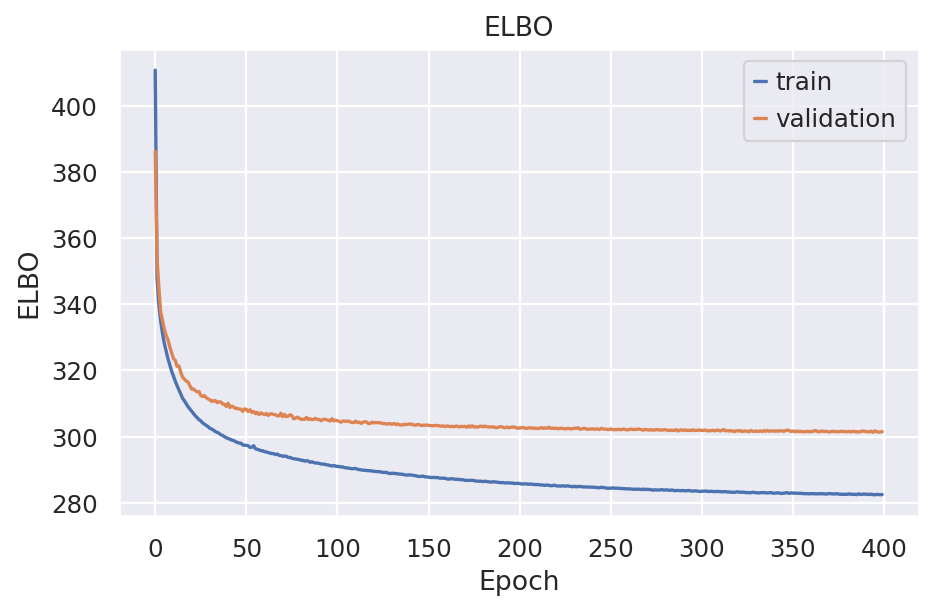

In [ ]:
# Negative ELBO (Evidence lower bound)
if "elbo_train" in hist:
    plot_metric("elbo_train", "elbo_validation", "ELBO", "ELBO")

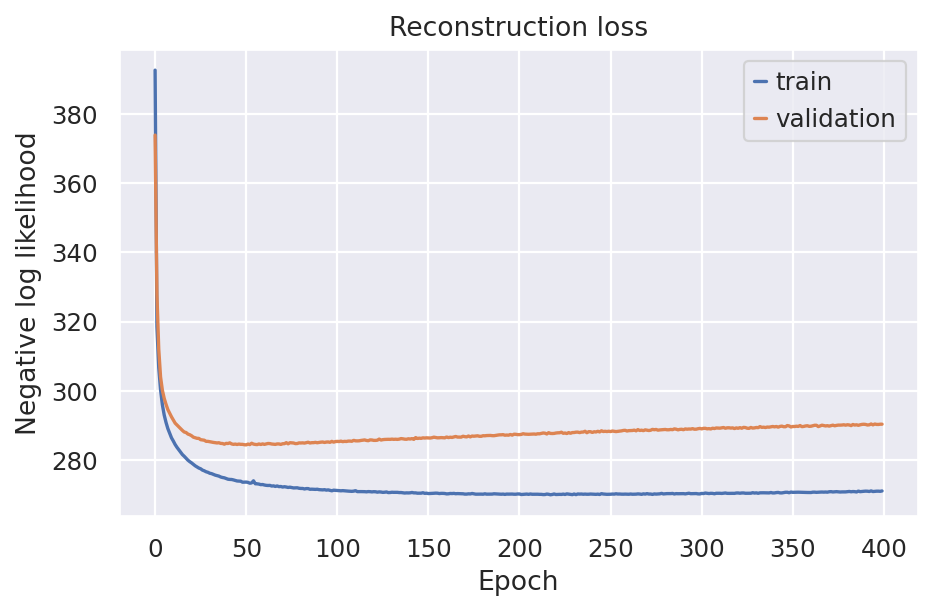

In [ ]:
# Reconstruction loss
plot_metric(
    "reconstruction_loss_train",
    "reconstruction_loss_validation",
    "Reconstruction loss",
    "Negative log likelihood",
)

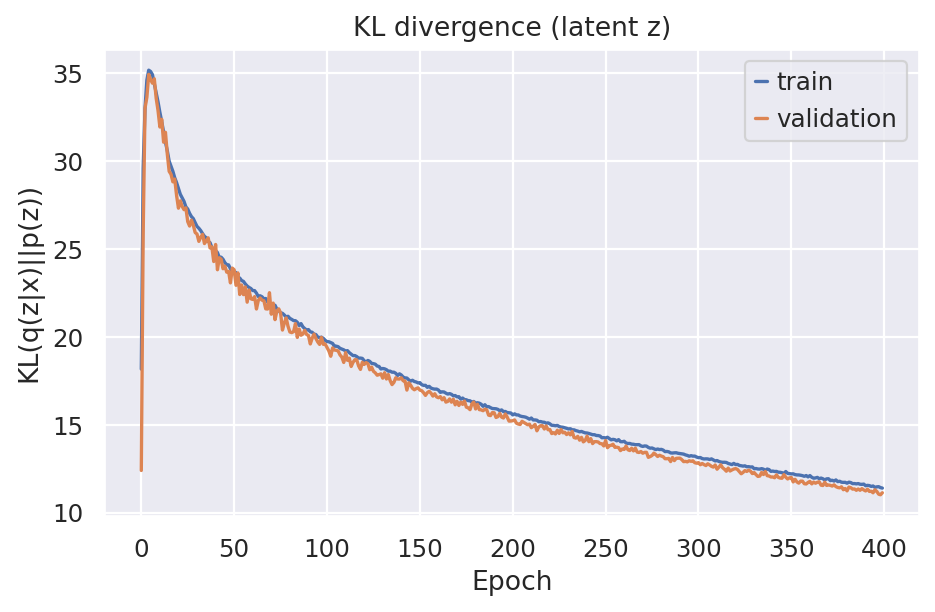

In [ ]:
# Local KL divergence
plot_metric(
    "kl_local_train", "kl_local_validation", "KL divergence (latent z)", "KL(q(z|x)||p(z))"
)

In [ ]:
# Model outputs: mean of approximate posterior
SCVI_LATENT_KEY = "X_scVI"

latent = model.get_latent_representation()
adata.obsm[SCVI_LATENT_KEY] = latent
latent.shape

(18641, 10)



`.obsm` and `.varm` are metadata for observations and variables (respectively) that have many dimensions. They are identified with keys.

Note that regardless of number of dimensions:
- `.obsm` length = `.n_obs`
- `.varm` length = `.n_vars`

In [ ]:
adata.obsm

AxisArrays with keys: _scvi_extra_categorical_covs, _scvi_extra_continuous_covs, X_scVI

In [ ]:
adata.varm

AxisArrays with keys: 

`.uns` is unstructured metadata. In our case we have `cell_type_colors` and many others from the preprocessing and modelling.

In [ ]:
# adata.uns

In [ ]:
adata_subset = adata[adata.obs.cell_type == "Fibroblast"]
latent_subset = model.get_latent_representation(adata_subset) # The model learned latent (embeddings) space
latent_subset.shape

INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


(2446, 10)

In [ ]:
denoised = model.get_normalized_expression(adata_subset, library_size=1e4) # the models estimated gene space
denoised.iloc[:5, :5]

,ISG15,TNFRSF18,VWA1,HES5,SPSB1
GTCAAGTCATGCCACG-1-HCAHeart7702879,1.234783,0.007705,1.298139,0.113646,4.845730
GAGTCATTCTCCGTGT-1-HCAHeart8287128,1.066659,0.006967,1.707562,0.104187,30.573809
CCTCTGATCGTGACAT-1-HCAHeart7702881,0.467331,0.005996,2.644341,0.005922,2.766680
CGCCATTCATCATCTT-1-H0035_apex,0.093189,0.027166,0.683704,0.049695,5.082754
TCGTAGAGTAGGACTG-1-H0015_septum,0.067421,0.000889,0.066487,0.009136,8.113749


In [ ]:
# Let’s store the normalized values back in the anndata.
SCVI_NORMALIZED_KEY = "scvi_normalized"

adata.layers[SCVI_NORMALIZED_KEY] = model.get_normalized_expression(library_size=10e4)

If you wish to obtain a full gene-space matrix with batch correction you must use model.get_normalized_expression(..., transform_batch=<reference_batch>). Without specifying transform_batch, the default decoded matrix is conditioned on each cell’s own batch and will therefore not remove batch effects, but a per-batch decoded expression, rather than a harmonized expression across batches.

In [ ]:
# Interoperability with Scanpy
# Visualization without batch correction

Scanpy is a powerful python library for visualization and downstream analysis of scRNA-seq data. We show here how to feed the objects produced by scvi-tools into a scanpy workflow.

First, we demonstrate the presence of nuisance variation with respect to nuclei/whole cell, age group, and donor by plotting the UMAP results of the top 30 PCA components for the raw count data.

NOTE: a nuisance variable is a random variable that is fundamental to the probabilistic model, but that is of no particular interest in itself or is no longer of any interest

In [ ]:
# run PCA then generate UMAP plots
sc.tl.pca(adata)
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=20)
sc.tl.umap(adata, min_dist=0.3)

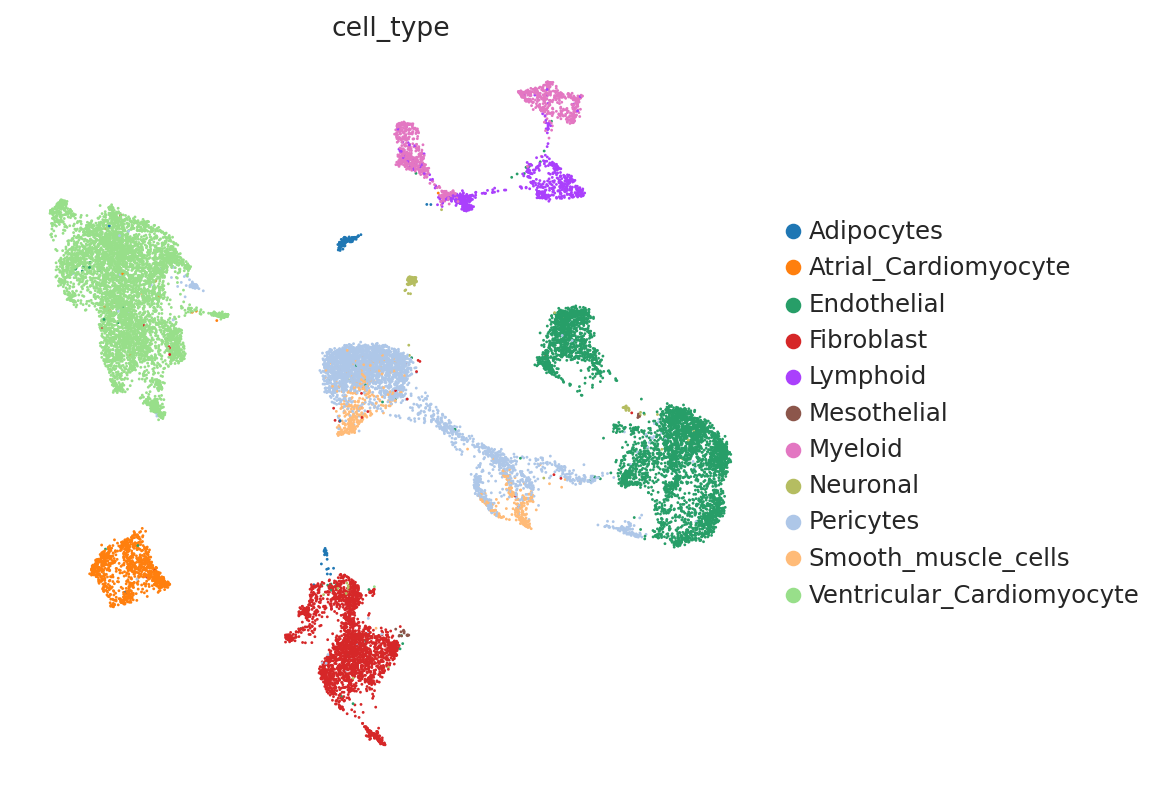

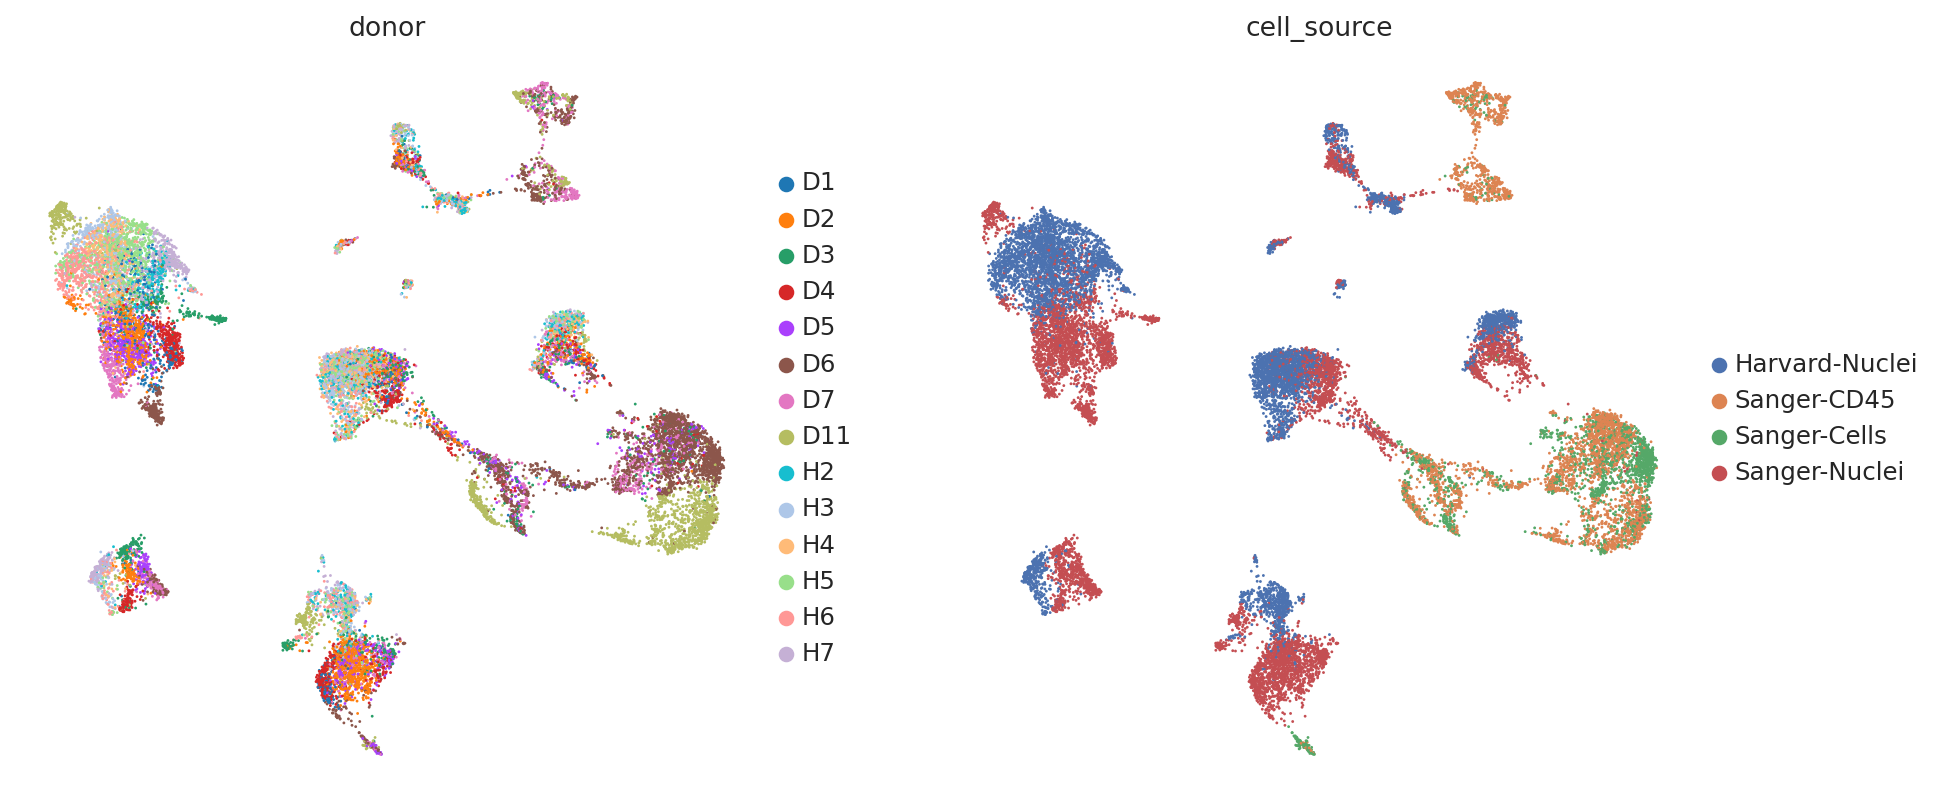

In [ ]:
sc.pl.umap(
    adata,
    color=["cell_type"],
    frameon=False,
)
sc.pl.umap(
    adata,
    color=["donor", "cell_source"],
    ncols=2,
    frameon=False,
)

In [ ]:
# Visualization with sc-vi batch correction
# use scVI latent space for UMAP generation
sc.pp.neighbors(adata, use_rep=SCVI_LATENT_KEY)
sc.tl.umap(adata, min_dist=0.3)

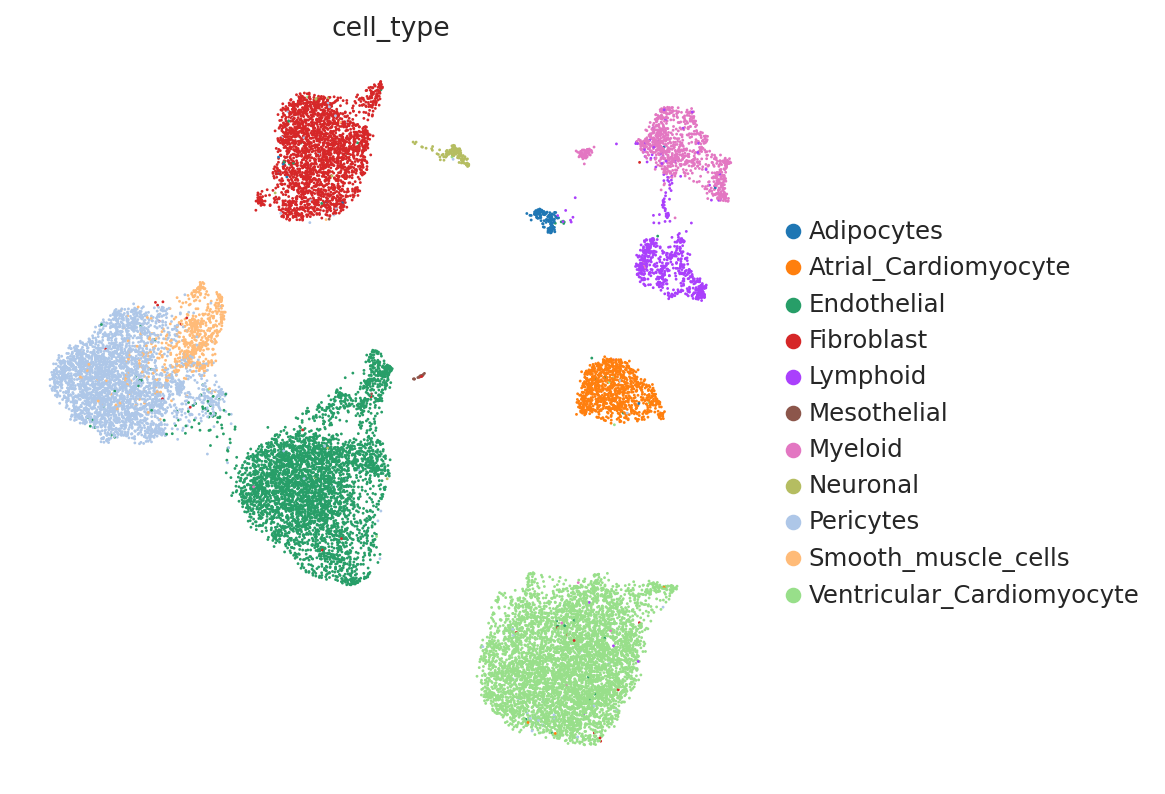

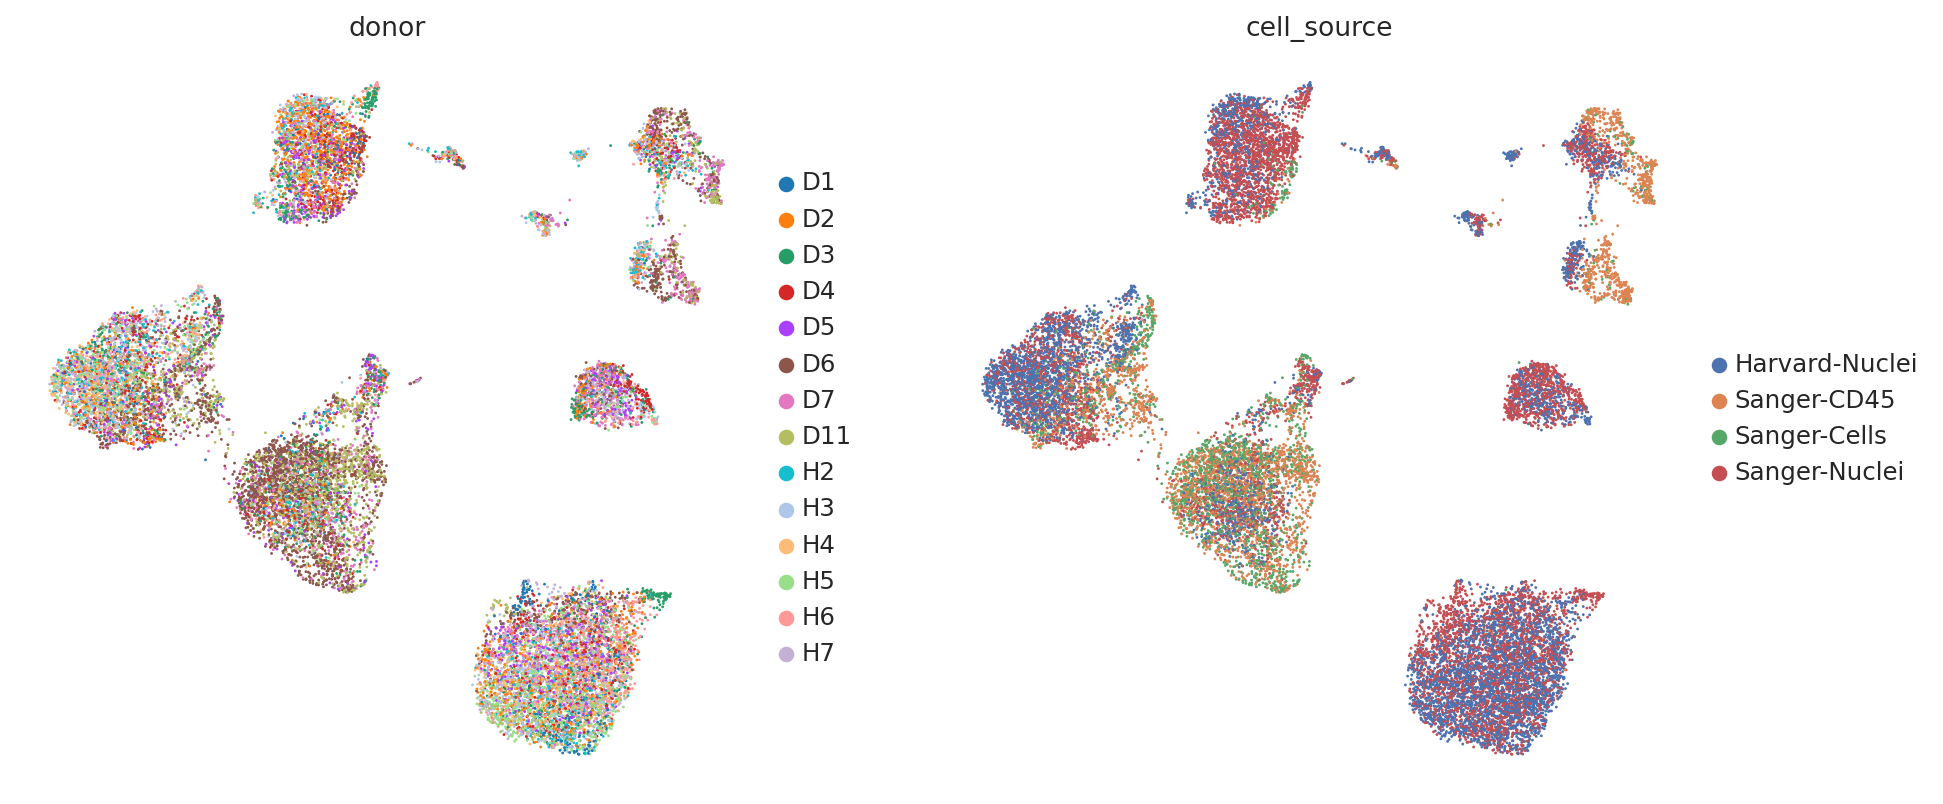

In [ ]:
sc.pl.umap(
    adata,
    color=["cell_type"],
    frameon=False,
)
sc.pl.umap(
    adata,
    color=["donor", "cell_source"],
    ncols=2,
    frameon=False,
)

In [ ]:
# Clustering on the scVI latent space
# neighbors were already computed using scVI
SCVI_CLUSTERS_KEY = "leiden_scVI"
sc.tl.leiden(adata, key_added=SCVI_CLUSTERS_KEY, resolution=0.5)

/tmp/ipykernel_14447/563433068.py:4: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, key_added=SCVI_CLUSTERS_KEY, resolution=0.5)


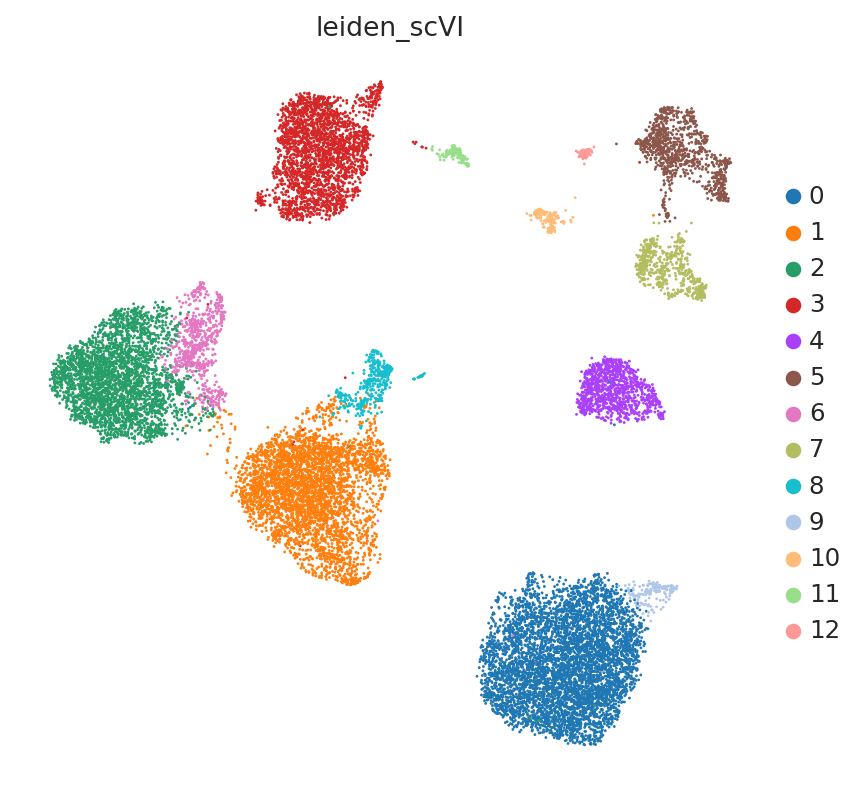

In [ ]:
sc.pl.umap(
    adata,
    color=[SCVI_CLUSTERS_KEY],
    frameon=False,
)

In [ ]:
# Differential expression
adata.obs.cell_type.head()

,cell_type
AACTCCCCACGAGAGT-1-HCAHeart7844001,Myeloid
ATAACGCAGAGCTGGT-1-HCAHeart7829979,Ventricular_Cardiomyocyte
GTCAAGTCATGCCACG-1-HCAHeart7702879,Fibroblast
GGTGATTCAAATGAGT-1-HCAHeart8102858,Endothelial
AGAGAATTCTTAGCAG-1-HCAHeart8102863,Endothelial


In [ ]:
de_df = model.differential_expression(
    groupby="cell_type", group1="Endothelial", group2="Fibroblast"
)
de_df.head()

DE...:   0%|          | 0/1 [00:00<?, ?it/s]

,proba_m1,proba_m2,bayes_factor,scale1,scale2,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,comparison,group1,group2
EGFL7,0.9978,0.0022,6.117091,0.007576,0.000424,2.376779,0.036795,0.741543,0.025756,89.507553,1.169474,Endothelial vs Fibroblast,Endothelial,Fibroblast
VWF,0.9972,0.0028,5.875328,0.016043,0.000528,5.072563,0.054375,0.808226,0.032298,169.693512,2.207696,Endothelial vs Fibroblast,Endothelial,Fibroblast
SLC9A3R2,0.9962,0.0038,5.568944,0.010278,0.000209,4.451492,0.045380,0.712339,0.034342,111.582703,1.657324,Endothelial vs Fibroblast,Endothelial,Fibroblast
STC1,0.9956,0.0044,5.421739,0.001786,0.000041,0.785346,0.004088,0.198832,0.003271,17.157606,0.194772,Endothelial vs Fibroblast,Endothelial,Fibroblast
PECAM1,0.9952,0.0048,5.334326,0.005572,0.000670,2.065984,0.075634,0.653930,0.054374,60.612019,3.404117,Endothelial vs Fibroblast,Endothelial,Fibroblast


In [ ]:
de_df = model.differential_expression(
    groupby="cell_type", group1="Lymphoid", group2="Fibroblast"
)
de_df.head()

DE...:   0%|          | 0/1 [00:00<?, ?it/s]

,proba_m1,proba_m2,bayes_factor,scale1,scale2,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,comparison,group1,group2
CORO1A,0.9982,0.0018,6.318161,0.004503,0.000041,1.451762,0.003679,0.471669,0.003271,40.512276,0.182122,Lymphoid vs Fibroblast,Lymphoid,Fibroblast
PTPRC,0.9962,0.0038,5.568944,0.011776,0.000170,2.000004,0.015944,0.741194,0.008994,129.915649,0.381665,Lymphoid vs Fibroblast,Lymphoid,Fibroblast
LCP1,0.9948,0.0052,5.253881,0.002425,0.000101,0.730476,0.004906,0.415008,0.004906,29.415621,0.251300,Lymphoid vs Fibroblast,Lymphoid,Fibroblast
TRBC1,0.9942,0.0058,5.144079,0.001960,0.000007,0.658500,0.002044,0.254211,0.001226,17.585066,0.052608,Lymphoid vs Fibroblast,Lymphoid,Fibroblast
CCL4,0.9940,0.0060,5.109976,0.010364,0.000030,4.583463,0.002044,0.483920,0.001635,120.337250,0.026005,Lymphoid vs Fibroblast,Lymphoid,Fibroblast


In [ ]:
de_df = model.differential_expression(groupby="cell_type", mode="change")
de_df.head()

DE...:   0%|          | 0/11 [00:00<?, ?it/s]

,proba_de,proba_not_de,bayes_factor,scale1,scale2,pseudocounts,delta,lfc_mean,lfc_median,lfc_std,...,raw_mean1,raw_mean2,non_zeros_proportion1,non_zeros_proportion2,raw_normalized_mean1,raw_normalized_mean2,is_de_fdr_0.05,comparison,group1,group2
GPAM,0.9972,0.0028,5.875328,0.022581,0.000215,0.000011,0.25,7.122216,7.150617,2.411983,...,17.372416,0.035791,0.896552,0.031520,280.340485,1.565905,True,Adipocytes vs Rest,Adipocytes,Rest
DGAT2,0.9958,0.0042,5.468460,0.004022,0.000047,0.000011,0.25,7.275119,7.247281,2.880639,...,2.682757,0.005028,0.593103,0.004866,43.613537,0.194096,True,Adipocytes vs Rest,Adipocytes,Rest
FASN,0.9956,0.0044,5.421739,0.009004,0.000137,0.000011,0.25,6.267750,6.350128,2.164534,...,7.062068,0.025086,0.841379,0.022167,129.074371,1.084626,True,Adipocytes vs Rest,Adipocytes,Rest
GPD1,0.9954,0.0046,5.377086,0.003009,0.000046,0.000011,0.25,6.955730,6.576396,2.806239,...,1.758620,0.007353,0.620690,0.007299,30.203791,0.255079,True,Adipocytes vs Rest,Adipocytes,Rest
PLIN1,0.9950,0.0050,5.293303,0.004803,0.000052,0.000011,0.25,7.960792,7.694875,3.168187,...,2.799999,0.004379,0.806897,0.004325,52.921761,0.196486,True,Adipocytes vs Rest,Adipocytes,Rest


In [ ]:
# extract top markers for each cluster using the DE results
markers = {}
cats = adata.obs.cell_type.cat.categories
for c in cats:
    cid = f"{c} vs Rest"
    cell_type_df = de_df.loc[de_df.comparison == cid]

    cell_type_df = cell_type_df[cell_type_df.lfc_mean > 0]

    cell_type_df = cell_type_df[cell_type_df["bayes_factor"] > 3]
    cell_type_df = cell_type_df[cell_type_df["non_zeros_proportion1"] > 0.1]

    markers[c] = cell_type_df.index.tolist()[:3]

In [ ]:
sc.tl.dendrogram(adata, groupby="cell_type", use_rep="X_scVI")

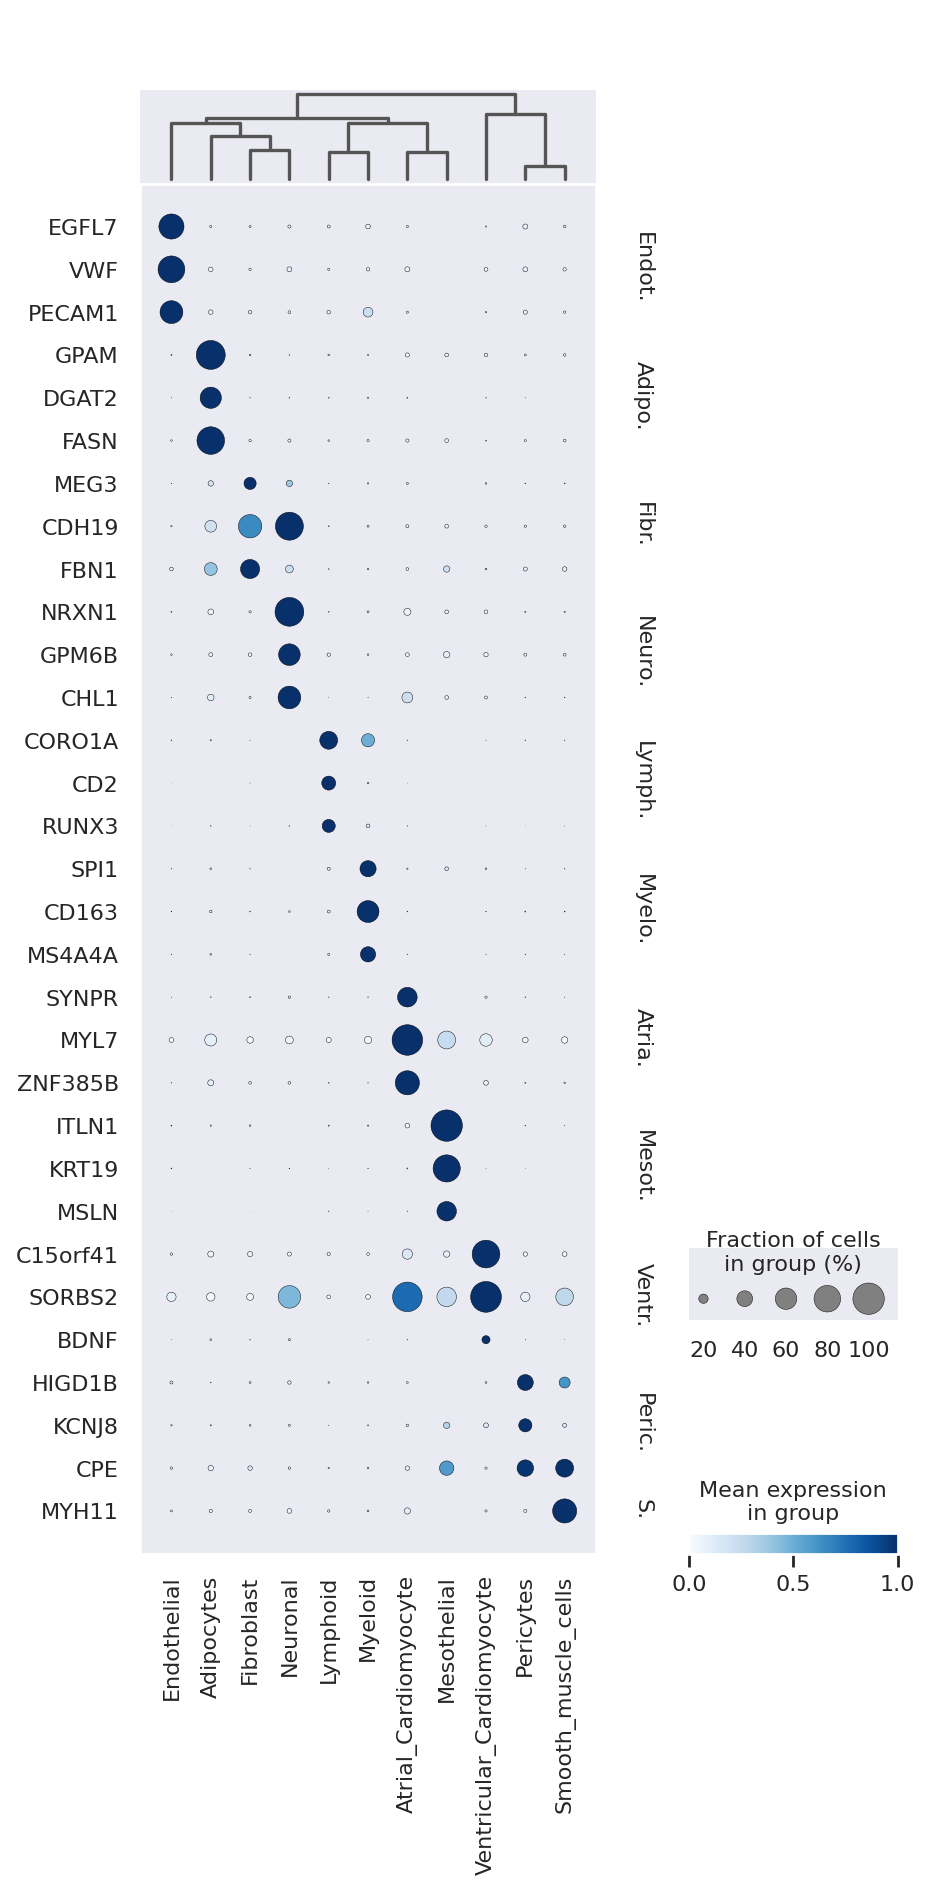

In [ ]:
sc.pl.dotplot(
    adata,
    markers,
    groupby="cell_type",
    dendrogram=True,
    color_map="Blues",
    swap_axes=True,
    use_raw=True,
    standard_scale="var",
)

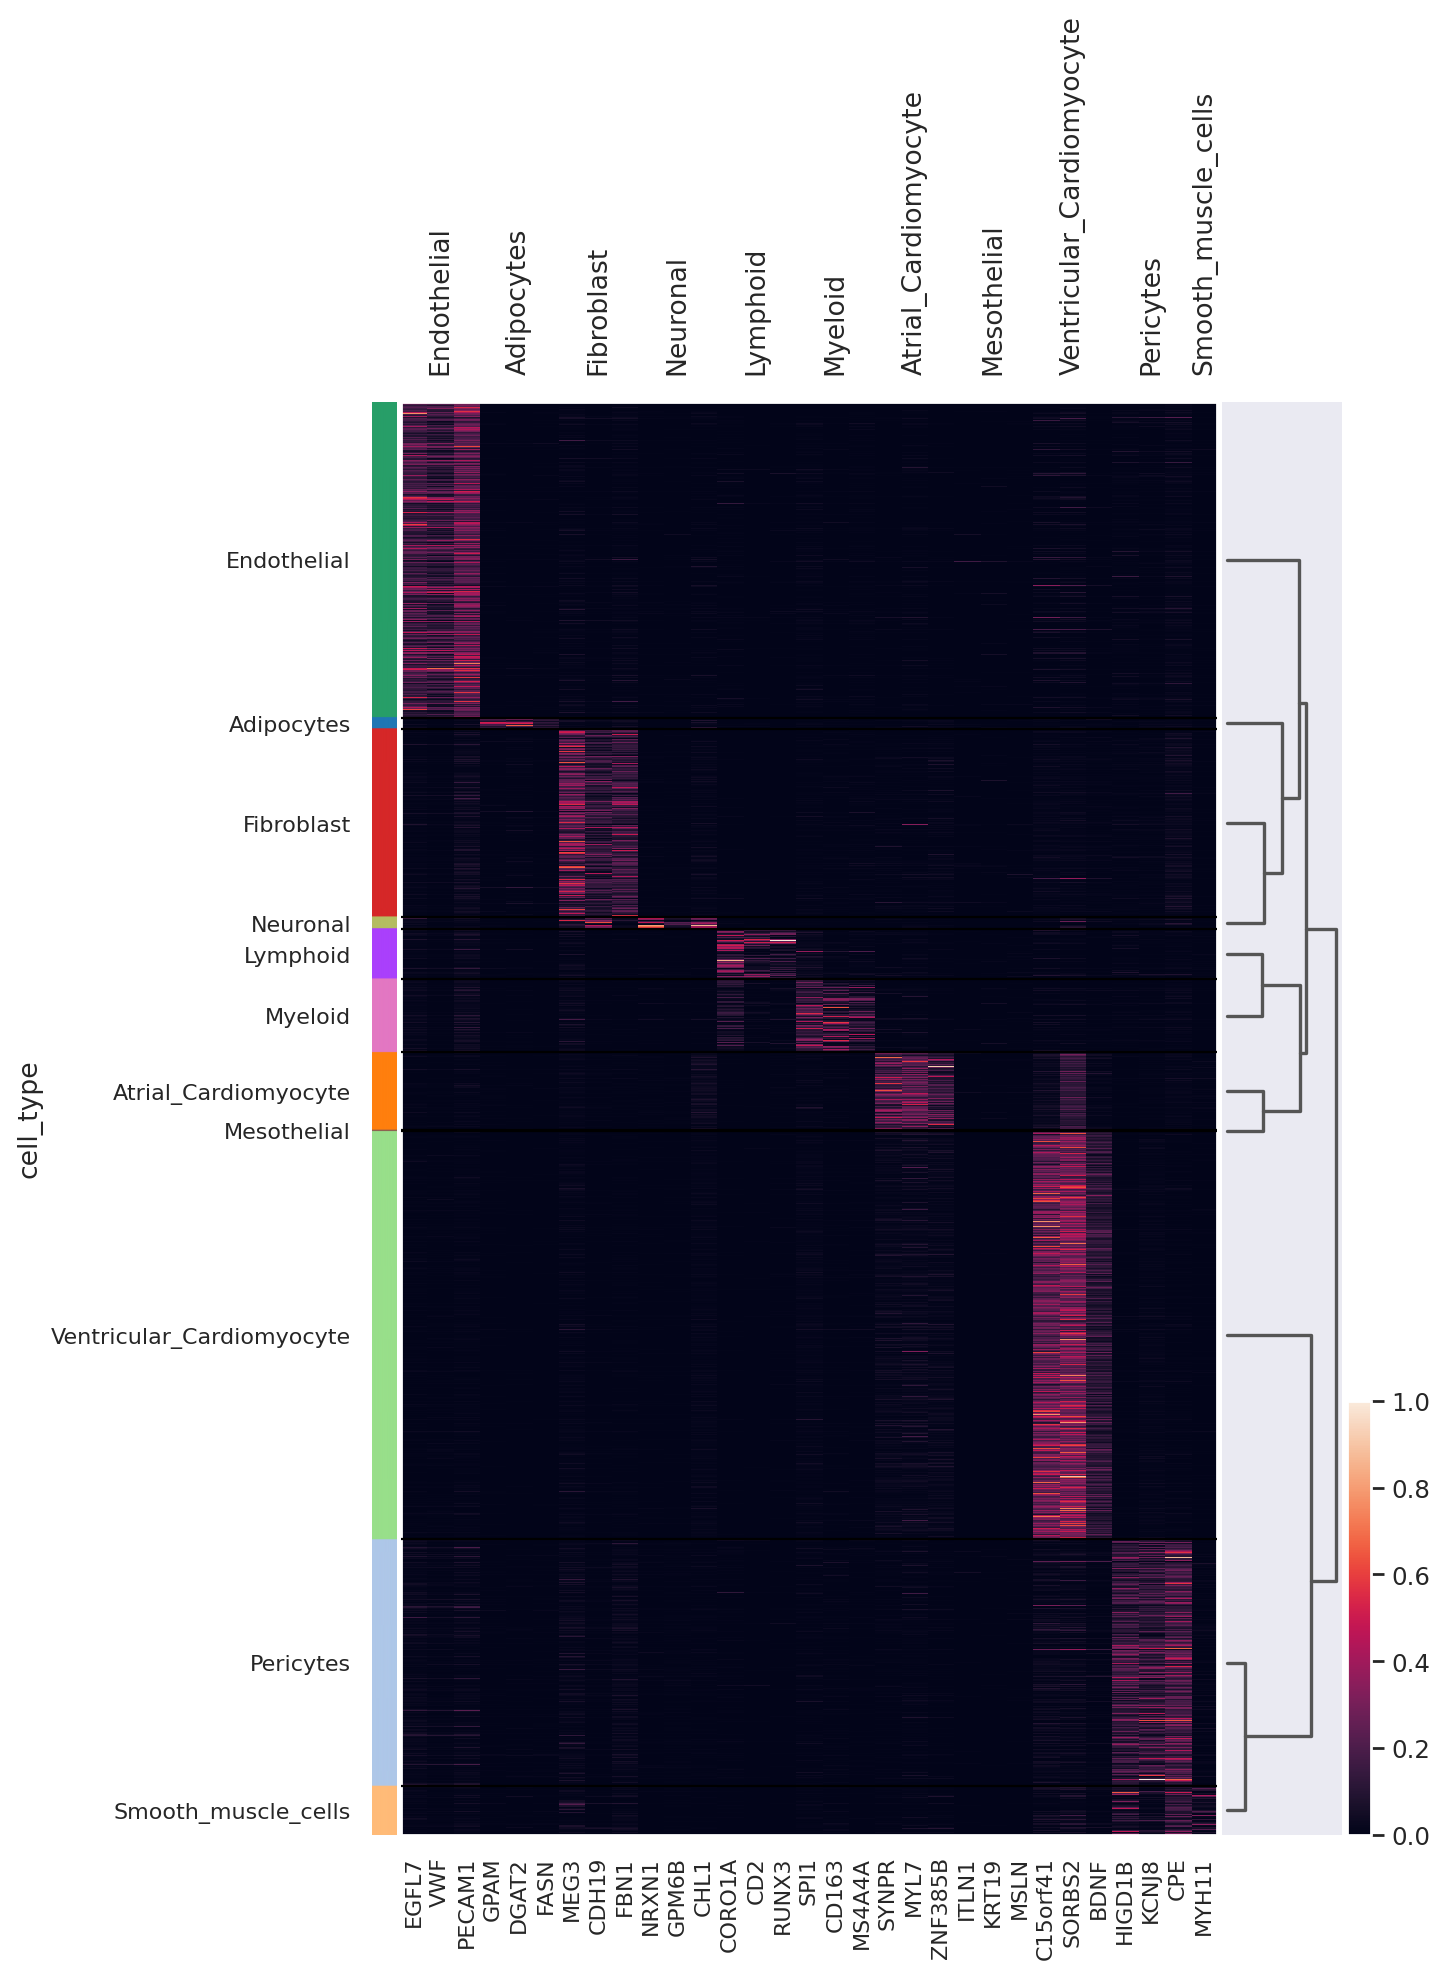

In [ ]:
sc.pl.heatmap(
    adata,
    markers,
    groupby="cell_type",
    layer="scvi_normalized", # scVI normalized gene expression values
    standard_scale="var",
    dendrogram=True,
    figsize=(8, 12),
)

In [ ]:
scvi.settings.verbosity # INFO

20

# Linearly decoded VAE

https://docs.scvi-tools.org/en/stable/tutorials/notebooks/scrna/linear_decoder.html

In [ ]:
adata_path = os.path.join(save_dir, "pbmc_10k_protein_v3.h5ad")
adata2 = sc.read(
    adata_path,
    backup_url="https://github.com/YosefLab/scVI-data/raw/master/pbmc_10k_protein_v3.h5ad?raw=true",
)

adata2

AnnData object with n_obs × n_vars = 6855 × 16727
    obs: 'n_genes', 'percent_mito', 'n_counts'
    var: 'n_cells', 'highly_variable', 'encode', 'hvg_encode'
    uns: 'protein_names'
    obsm: 'protein_expression'

In [ ]:
adata2.layers["counts"] = adata2.X.copy()  # preserve counts
sc.pp.normalize_total(adata2, target_sum=10e4)
sc.pp.log1p(adata2)
adata2.raw = adata2  # freeze the state in `.raw`

sc.pp.highly_variable_genes(
    adata2, flavor="seurat_v3", layer="counts", n_top_genes=1000, subset=True
)

In [ ]:
# subsample 1000 genes, train and fit ldvae
scvi.model.LinearSCVI.setup_anndata(adata2, layer="counts")
model2 = scvi.model.LinearSCVI(adata2, n_latent=10) # 10 latent dimensions

In [ ]:
model_dir = os.path.join(save_dir, "scvi_cluster_model")
# model.save(model_dir, overwrite=True)
model2 = scvi.model.LinearSCVI.load(model_dir, adata=adata2)

INFO     File /content/drive/MyDrive/scvi_data/scvi_cluster_model/model.pt already downloaded                      


In [ ]:
# model.train(max_epochs=250, plan_kwargs={"lr": 5e-3}, check_val_every_n_epoch=10)

<Axes: xlabel='epoch'>

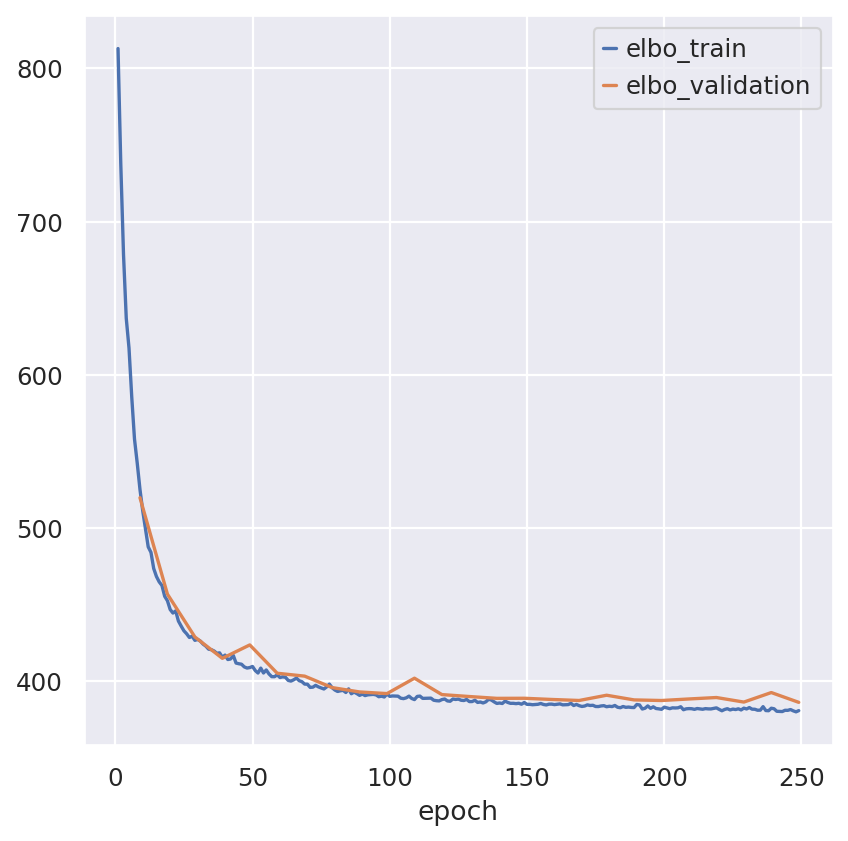

In [ ]:
# inspect convergence
train_elbo = model2.history["elbo_train"][1:]
test_elbo = model2.history["elbo_validation"]

ax = train_elbo.plot()
test_elbo.plot(ax=ax)

In [ ]:
# Extract and plot latent dimensions for cells
Z_hat = model2.get_latent_representation()
for i, z in enumerate(Z_hat.T):
    adata2.obs[f"Z_{i}"] = z

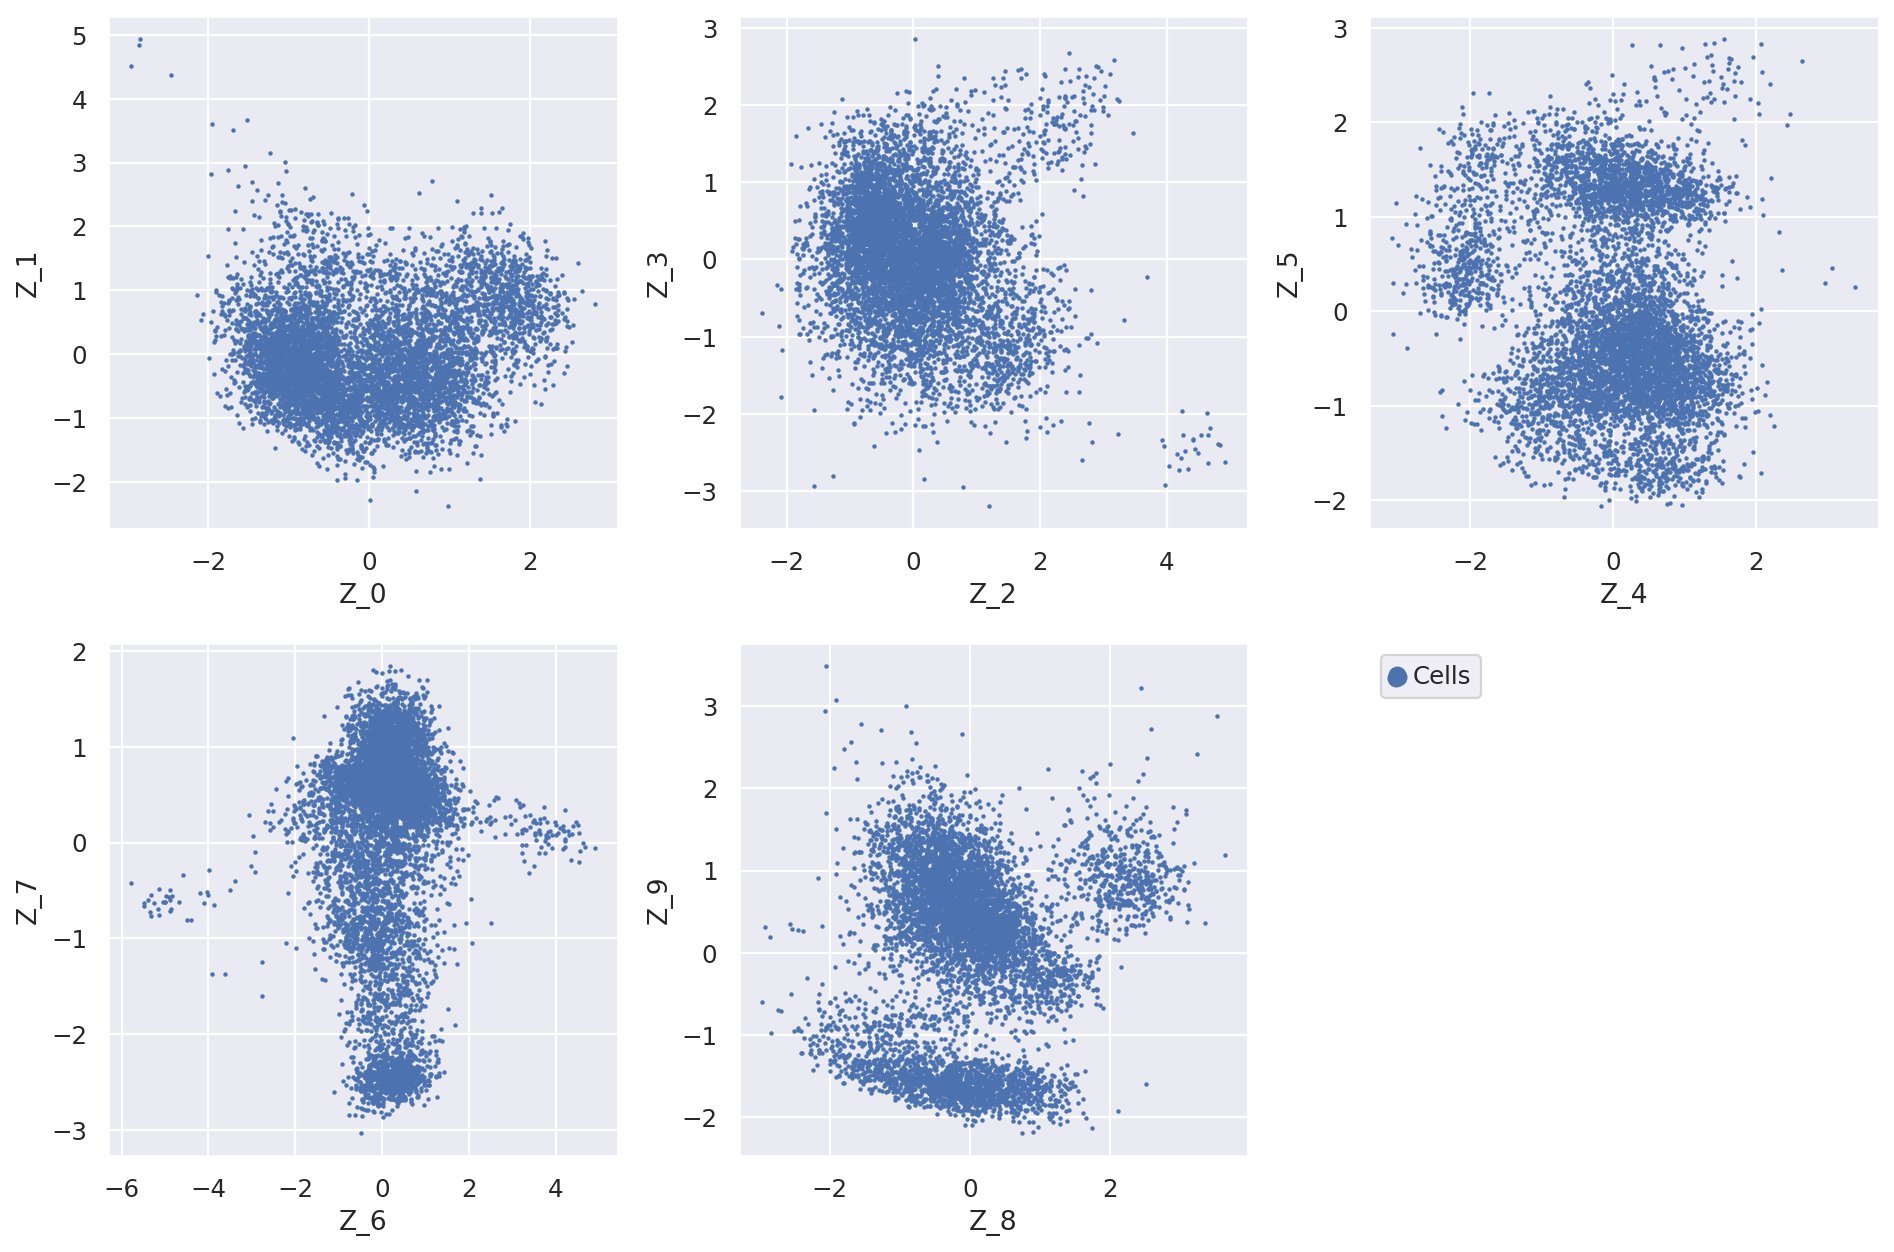

In [ ]:
fig = plt.figure(figsize=(12, 8))

for f in range(0, 9, 2):
    plt.subplot(2, 3, int(f / 2) + 1)

    plt.scatter(adata2.obs[f"Z_{f}"], adata2.obs[f"Z_{f + 1}"], marker=".", s=4, label="Cells")

    plt.xlabel(f"Z_{f}")
    plt.ylabel(f"Z_{f + 1}")

plt.subplot(2, 3, 6)
plt.scatter(adata2.obs[f"Z_{f}"], adata2.obs[f"Z_{f + 1}"], marker=".", label="Cells", s=4)
plt.scatter(adata2.obs[f"Z_{f}"], adata2.obs[f"Z_{f + 1}"], c="w", label=None)
plt.gca().set_frame_on(False)
plt.gca().axis("off")

lgd = plt.legend(scatterpoints=3, loc="upper left")
for handle in lgd.legend_handles:
    handle.set_sizes([200])


plt.tight_layout()

The question now is how does the latent dimensions link to genes?

For a given cell x, the expression of the gene g is proportional to x_g = w_(1, g) * z_1 + … + w_(10, g) * z_10. Moving from low values to high values in z_1 will mostly affect expression of genes with large w_(1, :) weights. We can extract these weights from the LDVAE model, and identify which genes have high weights for each latent dimension.

In [ ]:
loadings = model2.get_loadings()
loadings.head()

,Z_0,Z_1,Z_2,Z_3,Z_4,Z_5,Z_6,Z_7,Z_8,Z_9
index,,,,,,,,,,
AL645608.8,0.327423,0.230345,0.221605,0.155097,0.710687,0.021936,0.539928,0.364580,0.006802,-0.087032
HES4,0.326295,-0.105305,0.529336,0.009672,0.538394,0.055475,0.671048,0.355891,-0.343190,-0.104033
ISG15,0.342266,0.086391,-0.074435,-0.305550,0.331916,-0.327091,0.233611,0.076719,-0.445634,0.413995
TNFRSF18,1.647511,0.407101,0.001297,-0.777202,0.022641,0.182149,0.111915,-0.807825,-0.869903,0.970262
TNFRSF4,1.523678,0.046359,-0.232859,-0.626365,0.146514,-0.052983,0.000879,-0.056055,-0.952527,1.166195


In [ ]:
print(
    "Top loadings by magnitude\n------------------------------------------------------------------"
    "---------------------"
)
for clmn_ in loadings:
    loading_ = loadings[clmn_].sort_values()
    fstr = clmn_ + ":\t"
    fstr += "\t".join([f"{i}, {loading_[i]:.2}" for i in loading_.head(5).index])
    fstr += "\n\t...\n\t"
    fstr += "\t".join([f"{i}, {loading_[i]:.2}" for i in loading_.tail(5).index])
    print(
        fstr
        + "\n-------------------------------------------------------------------------------------"
        "--\n"
    )

Top loadings by magnitude
---------------------------------------------------------------------------------------
Z_0:	KCNG1, -1.2	F13A1, -1.1	RNASE1, -1.1	FAM111B, -1.0	CAVIN3, -1.0
	...
	TNFRSF18, 1.6	LTK, 1.7	COL5A3, 1.8	SLC4A10, 1.8	KLRB1, 1.9
---------------------------------------------------------------------------------------

Z_1:	AL031432.1, -0.94	FPR3, -0.91	CERS3, -0.89	LINC02076, -0.89	FZD8, -0.85
	...
	MSLN, 0.91	CXCR6, 0.94	COL5A3, 0.98	GZMK, 1.0	GNG11, 1.1
---------------------------------------------------------------------------------------

Z_2:	FOXP3, -1.6	PMCH, -1.5	ARG1, -1.3	AC133644.2, -1.2	C11ORF96, -1.2
	...
	C1QB, 0.95	PPM1J, 0.97	IL3RA, 1.0	PLD4, 1.0	S100B, 1.1
---------------------------------------------------------------------------------------

Z_3:	VPREB1, -1.6	PCDH9, -1.6	MPIG6B, -1.5	PTCRA, -1.4	GNAZ, -1.4
	...
	VMO1, 0.7	AC004817.3, 0.7	IL10, 0.75	S100B, 0.85	IGLC6, 0.93
--------------------------------------------------------------------------------

It is important to keep in mind that unlike traditional PCA, these latent variables are not ordered. Z_0 does not necessarily explain more variance than Z_1.

These top genes can be interpreted as following most of the structural variation in the data.

The LinearSCVI model further supports the same scVI functionality as the SCVI model, so all posterior methods work the same. Here we show how to use scanpy to visualize the latent space.

In [ ]:
SCVI_LATENT_KEY = "X_scVI"
SCVI_CLUSTERS_KEY = "leiden_scVI"

adata2.obsm[SCVI_LATENT_KEY] = Z_hat
sc.pp.neighbors(adata2, use_rep=SCVI_LATENT_KEY, n_neighbors=20)
sc.tl.umap(adata2, min_dist=0.3)
sc.tl.leiden(adata2, key_added=SCVI_CLUSTERS_KEY, resolution=0.8)

/tmp/ipykernel_14447/4272449041.py:7: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata2, key_added=SCVI_CLUSTERS_KEY, resolution=0.8)


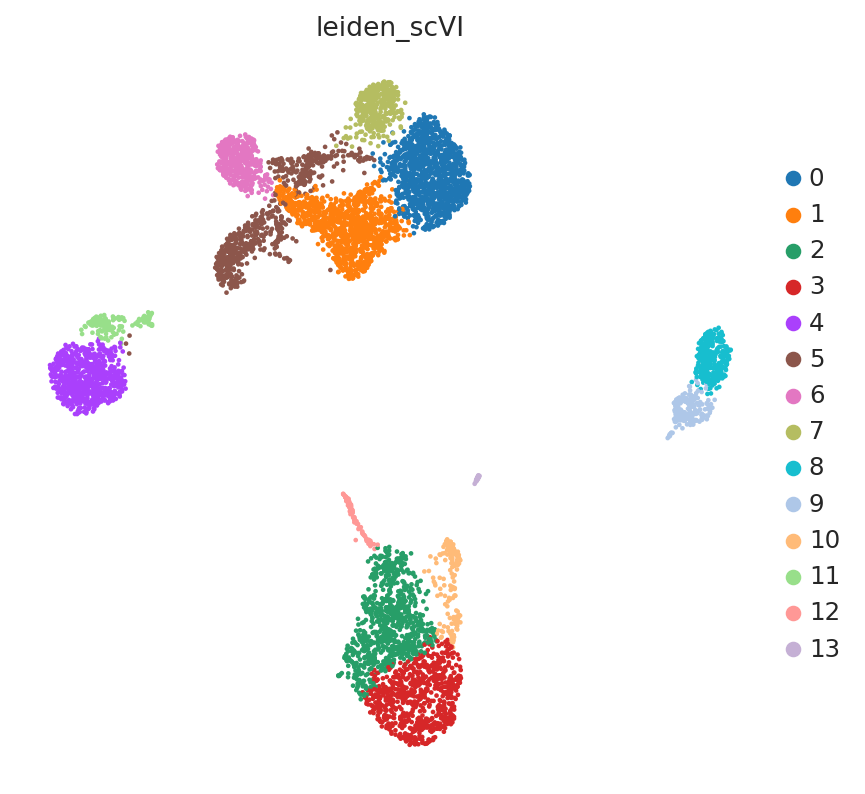

In [ ]:
sc.pl.umap(adata2, color=[SCVI_CLUSTERS_KEY])

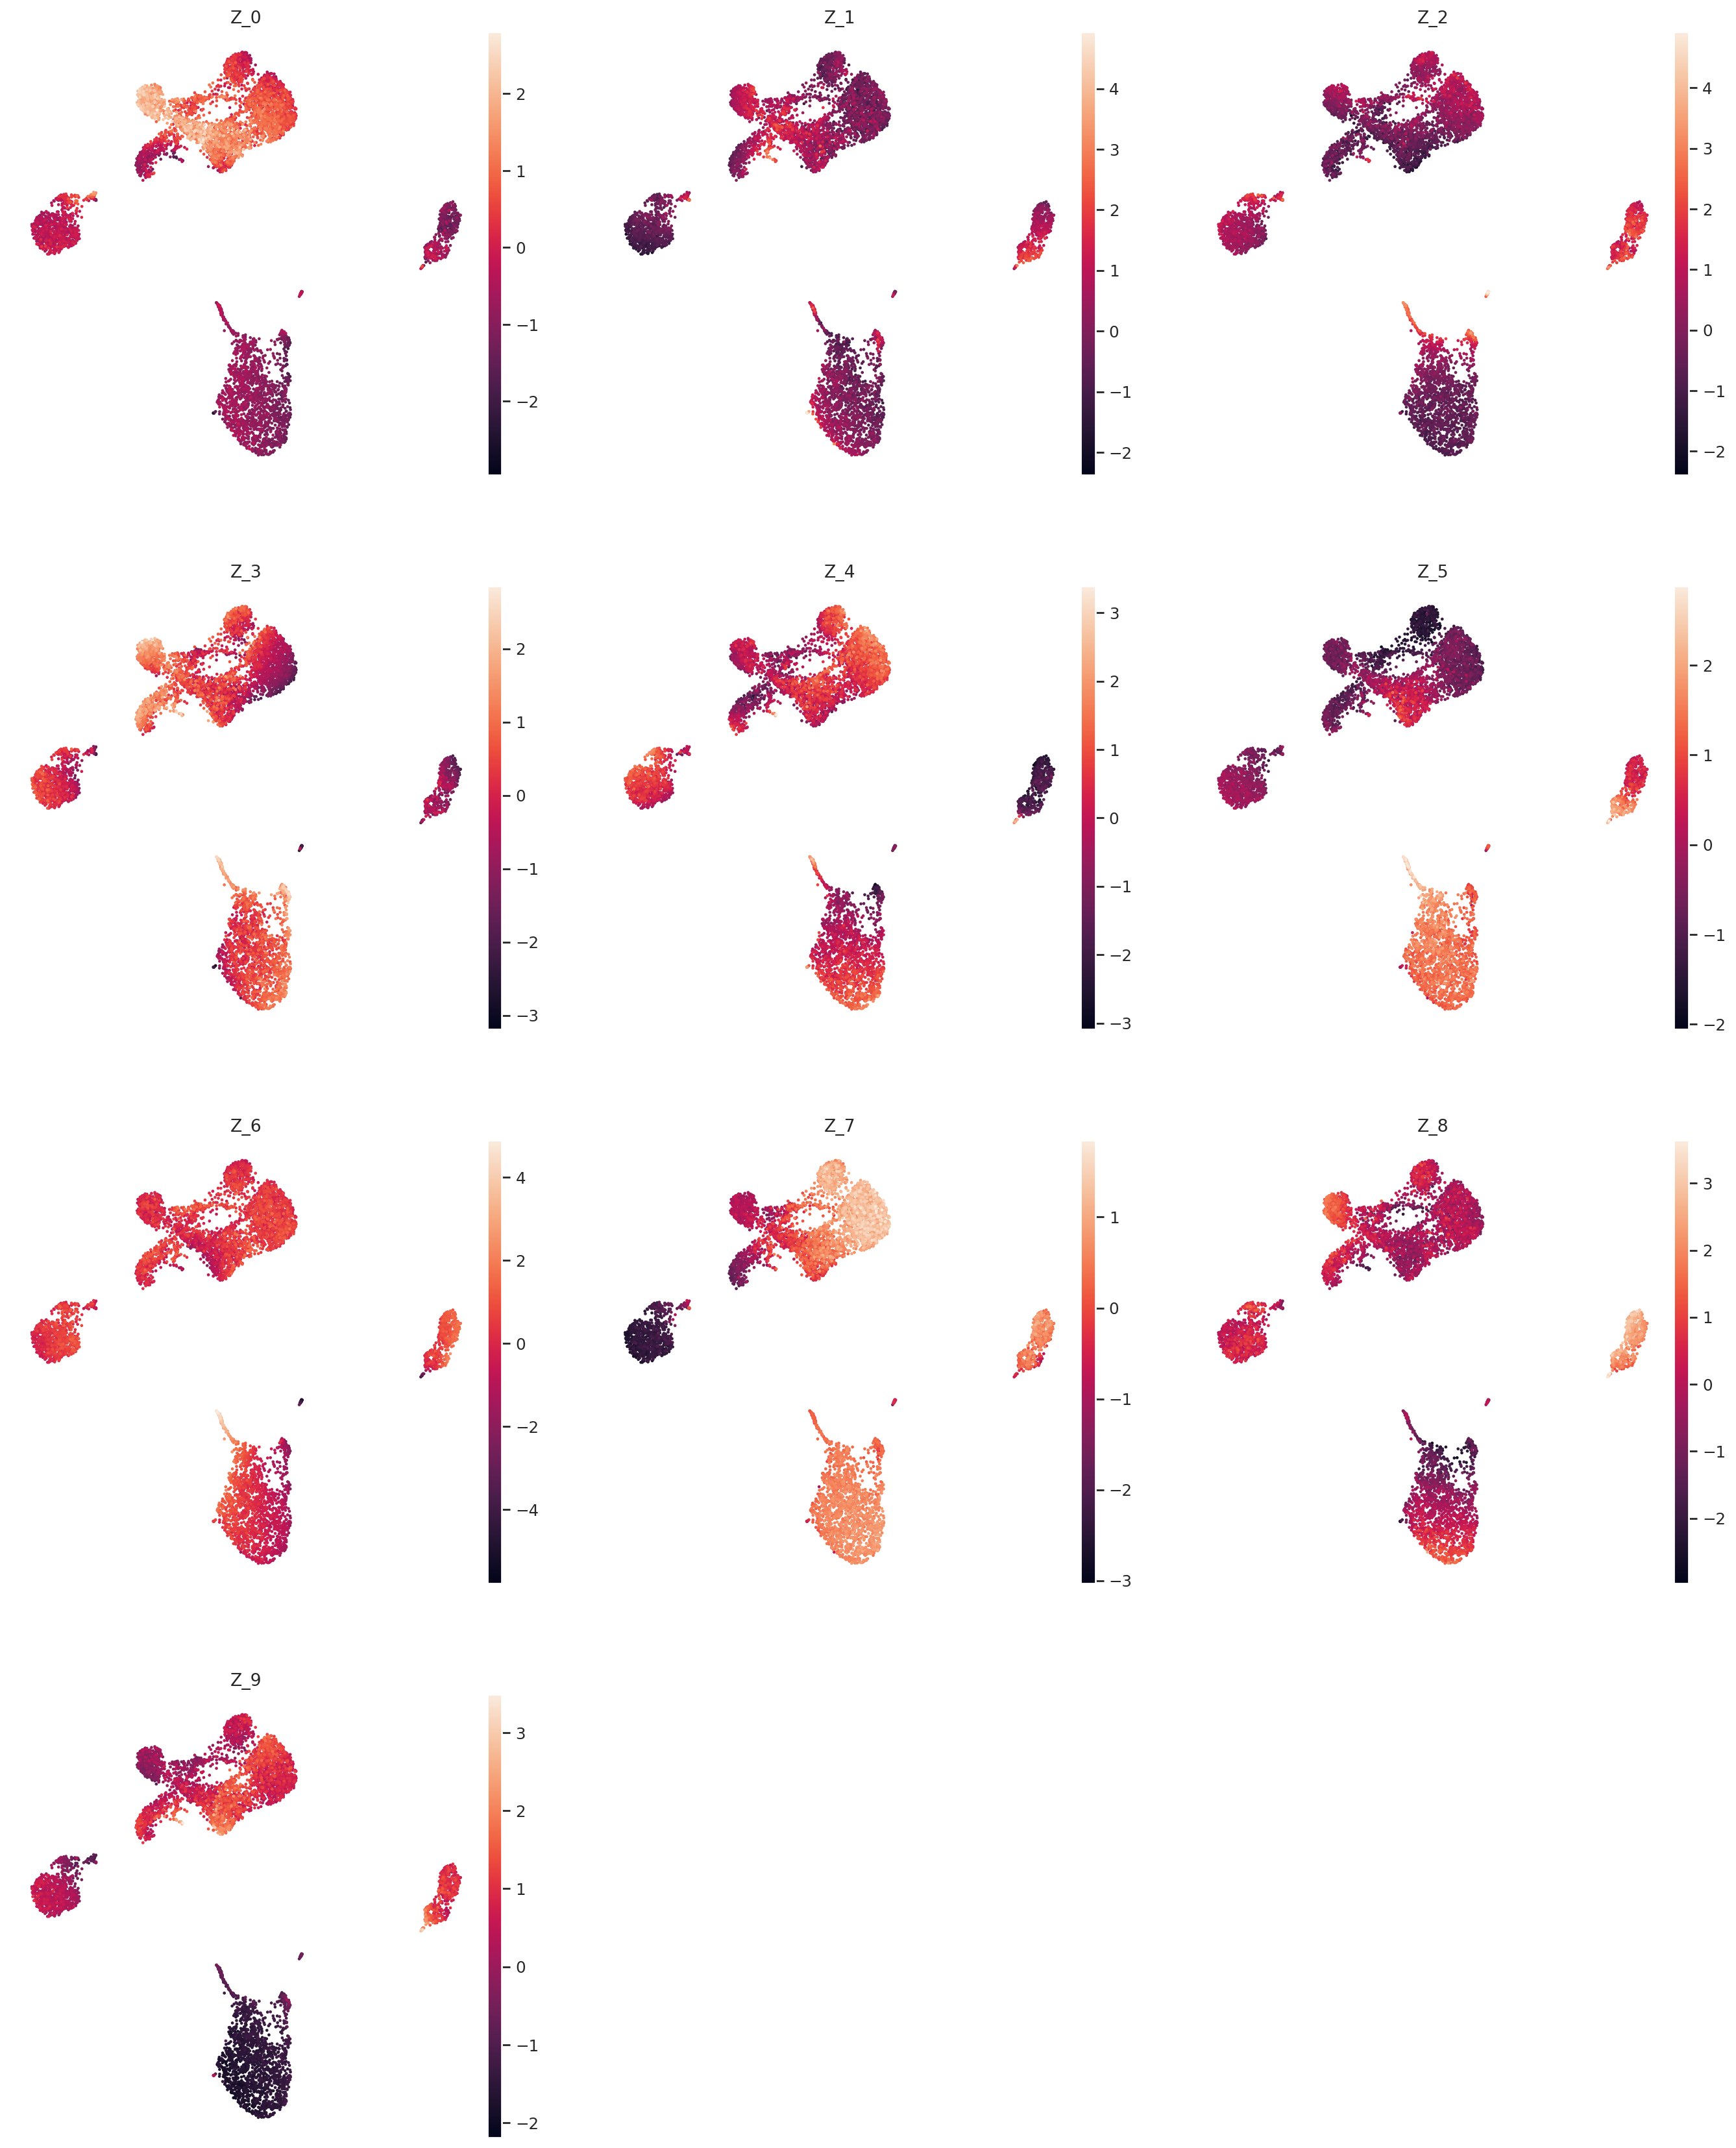

In [ ]:
zs = [f"Z_{i}" for i in range(model2.n_latent)]
sc.pl.umap(adata2, color=zs, ncols=3)

In [ ]:
model_dir = os.path.join(save_dir, "scvi_cluster_model")
# model.save(model_dir, overwrite=True)
model2 = scvi.model.LinearSCVI.load(model_dir, adata=adata2)

INFO     File /content/drive/MyDrive/scvi_data/scvi_cluster_model/model.pt already downloaded                      


# Reunion Marzo
- Ver para cada tipo de célula el gen con mayor nivel de expresión
- Ver T-SNE de cada tejido
-	Ver media y varianza representativo de cada tipo de tejido

In [ ]:
adata2

AnnData object with n_obs × n_vars = 6855 × 1000
    obs: 'n_genes', 'percent_mito', 'n_counts', '_scvi_batch', '_scvi_labels', 'Z_0', 'Z_1', 'Z_2', 'Z_3', 'Z_4', 'Z_5', 'Z_6', 'Z_7', 'Z_8', 'Z_9', 'leiden_scVI'
    var: 'n_cells', 'highly_variable', 'encode', 'hvg_encode', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'protein_names', 'log1p', 'hvg', '_scvi_uuid', '_scvi_manager_uuid', 'neighbors', 'umap', 'leiden_scVI', 'leiden_scVI_colors'
    obsm: 'protein_expression', 'X_scVI', 'X_umap'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [ ]:
model2

LinearSCVI Model with the following params: 
n_hidden: 128, n_latent: 10, n_layers: 1, dropout_rate: 0.1, dispersion: gene, gene_likelihood: nb, 
latent_distribution: normal
Training status: Trained
Model's adata is minified?: False

In [ ]:
adata2.var_names

Index(['AL645608.8', 'HES4', 'ISG15', 'TNFRSF18', 'TNFRSF4', 'SLC2A5', 'RBP7',
       'PGD', 'TNFRSF1B', 'PADI4',
       ...
       'TYMP', 'ODF3B', 'APP', 'MAP3K7CL', 'OLIG1', 'IFNGR2', 'MX1', 'COL6A2',
       'S100B', 'MT-CO1'],
      dtype='object', name='index', length=1000)

In [ ]:
# From https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html
# Ver para un tipo de celula el gen con mayor nivel de expresion (?)

# TNFRSF variables
adata2.var["tnfr"] = adata2.var_names.str.startswith("TNFRSF-")
# RBP variables
adata2.var["rbp"] = adata2.var_names.str.startswith(("RBP"))
# OLIG variables
adata2.var["olig"] = adata2.var_names.str.startswith("OLIG-")


In [ ]:
sc.pp.calculate_qc_metrics(adata2, qc_vars=["tnfr", "rbp", "olig"], inplace=True, log1p=True)
# https://scanpy.readthedocs.io/en/stable/generated/scanpy.pp.calculate_qc_metrics.html

In [ ]:
# adata.obs

In [ ]:
adata2.var_names

Index(['AL645608.8', 'HES4', 'ISG15', 'TNFRSF18', 'TNFRSF4', 'SLC2A5', 'RBP7',
       'PGD', 'TNFRSF1B', 'PADI4',
       ...
       'TYMP', 'ODF3B', 'APP', 'MAP3K7CL', 'OLIG1', 'IFNGR2', 'MX1', 'COL6A2',
       'S100B', 'MT-CO1'],
      dtype='object', name='index', length=1000)

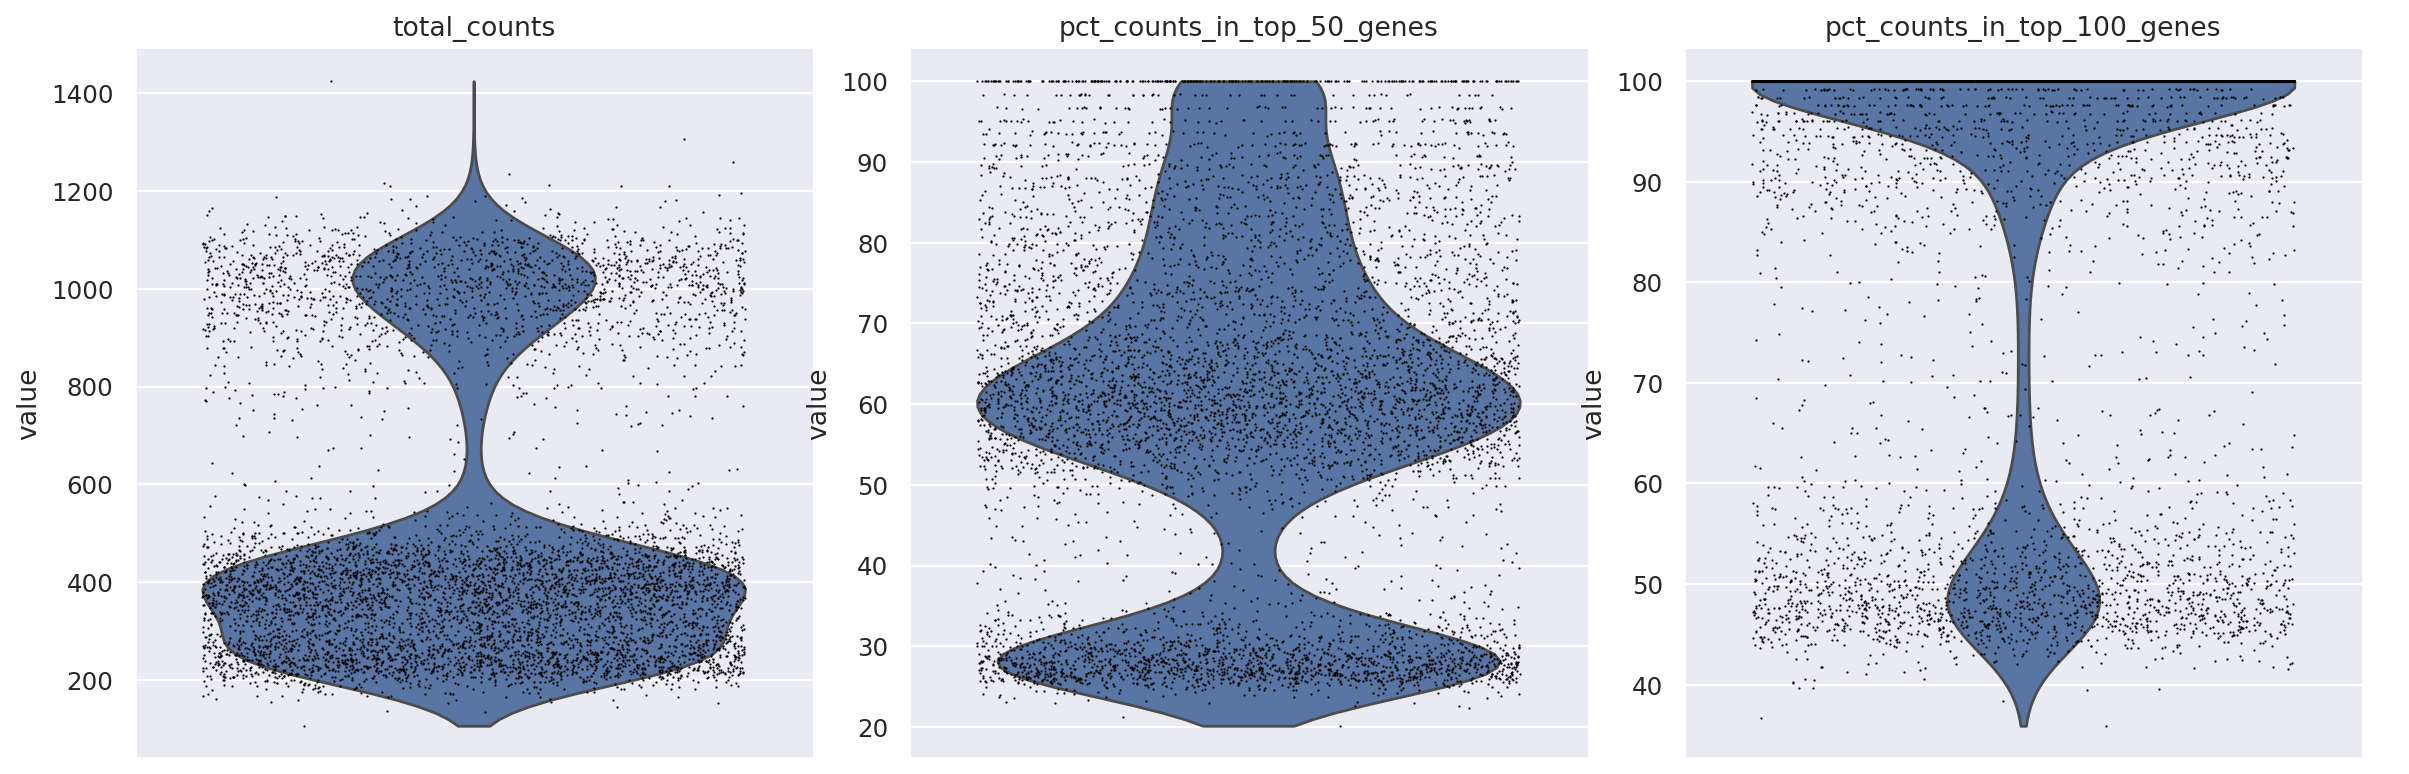

In [ ]:
# Observation level metrics
sc.pl.violin(
    adata2,
    ["total_counts", "pct_counts_in_top_50_genes", "pct_counts_in_top_100_genes"],
    jitter=0.4,
    multi_panel=True,
)

# Gave error
# total_genes_by_counts

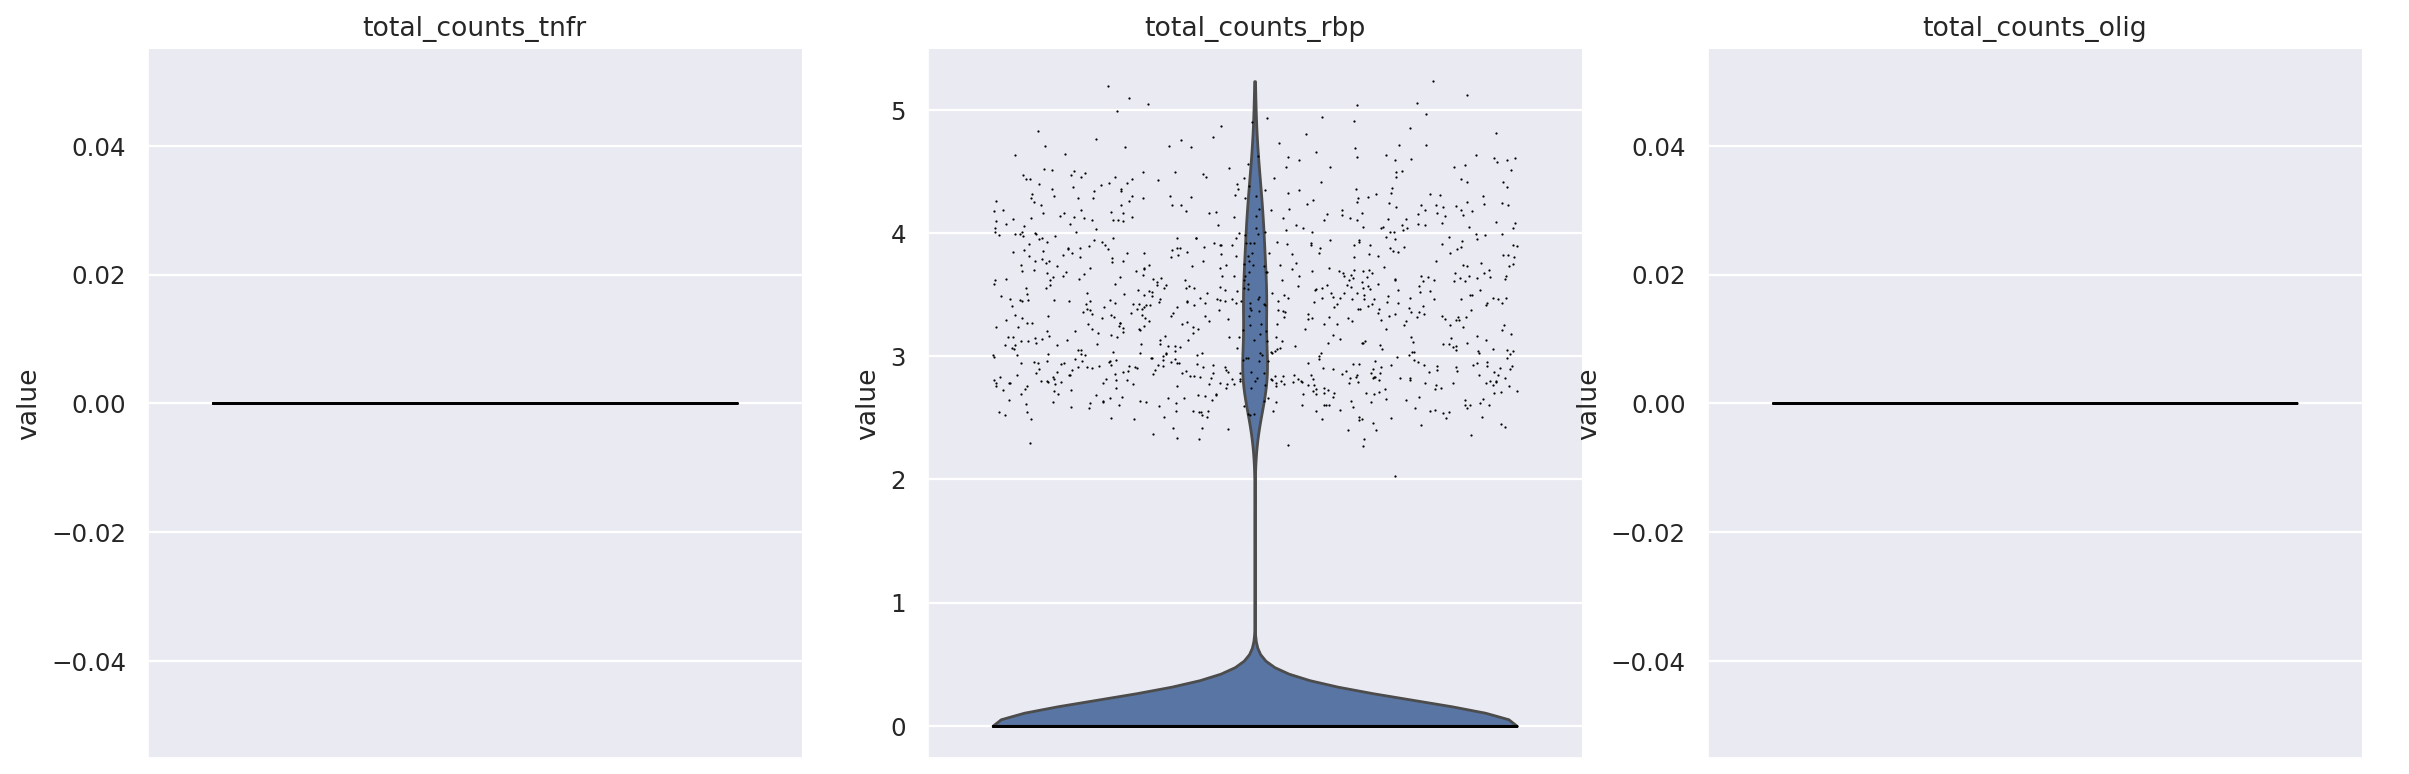

In [ ]:
sc.pl.violin(
    adata2,
    ["total_counts_tnfr", "total_counts_rbp", "total_counts_olig"],
    jitter=0.4,
    multi_panel=True,
)

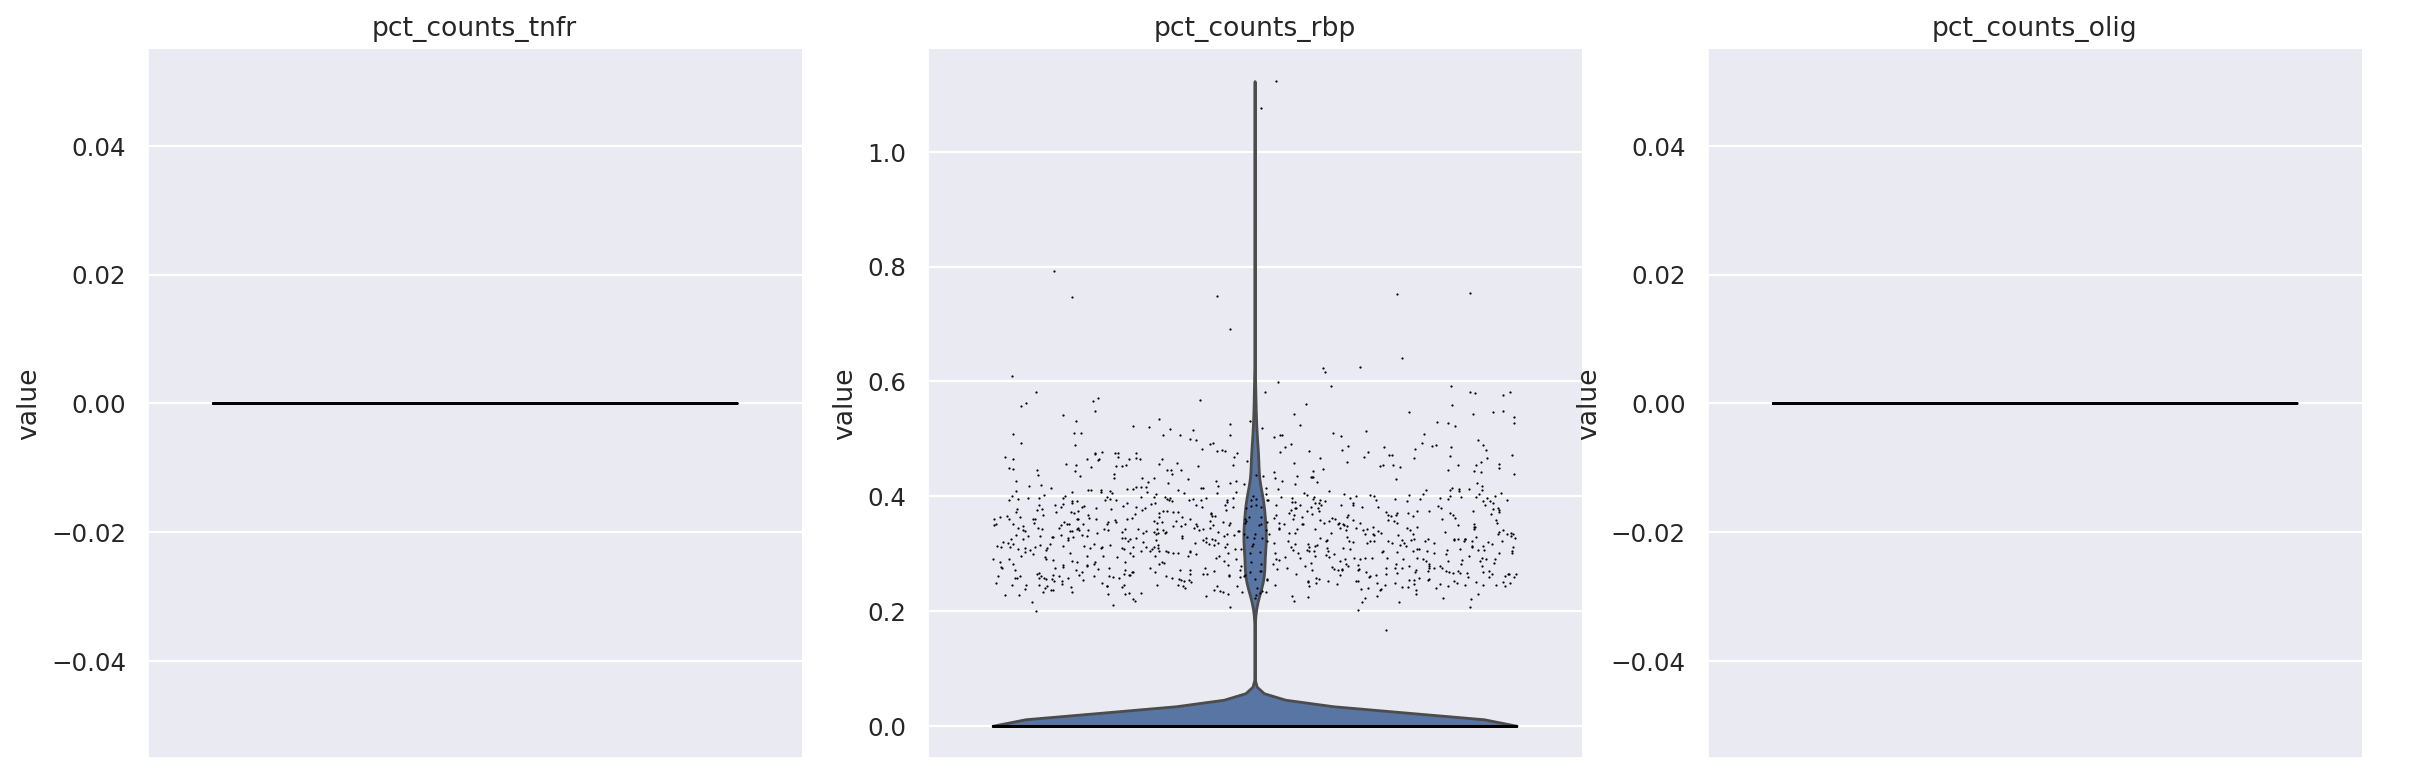

In [ ]:
sc.pl.violin(
    adata2,
    ["pct_counts_tnfr", "pct_counts_rbp", "pct_counts_olig"],
    jitter=0.4,
    multi_panel=True,
)

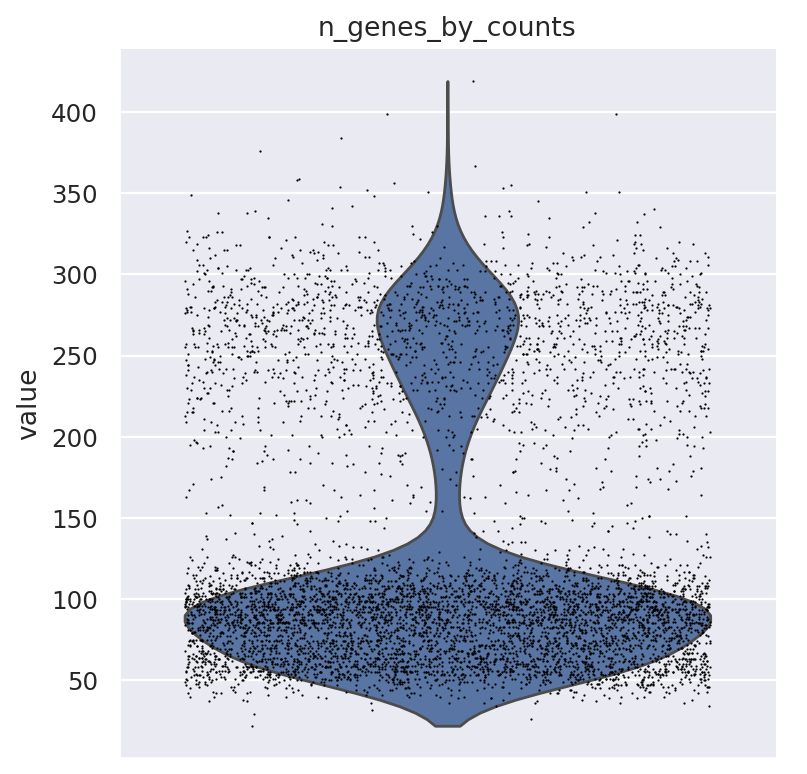

In [ ]:
# Variable level metrics
sc.pl.violin(
    adata2,
    ["n_genes_by_counts"],
    jitter=0.4,
    multi_panel=True,
)

# Gave error
# mean_counts
# n_cells_by_counts

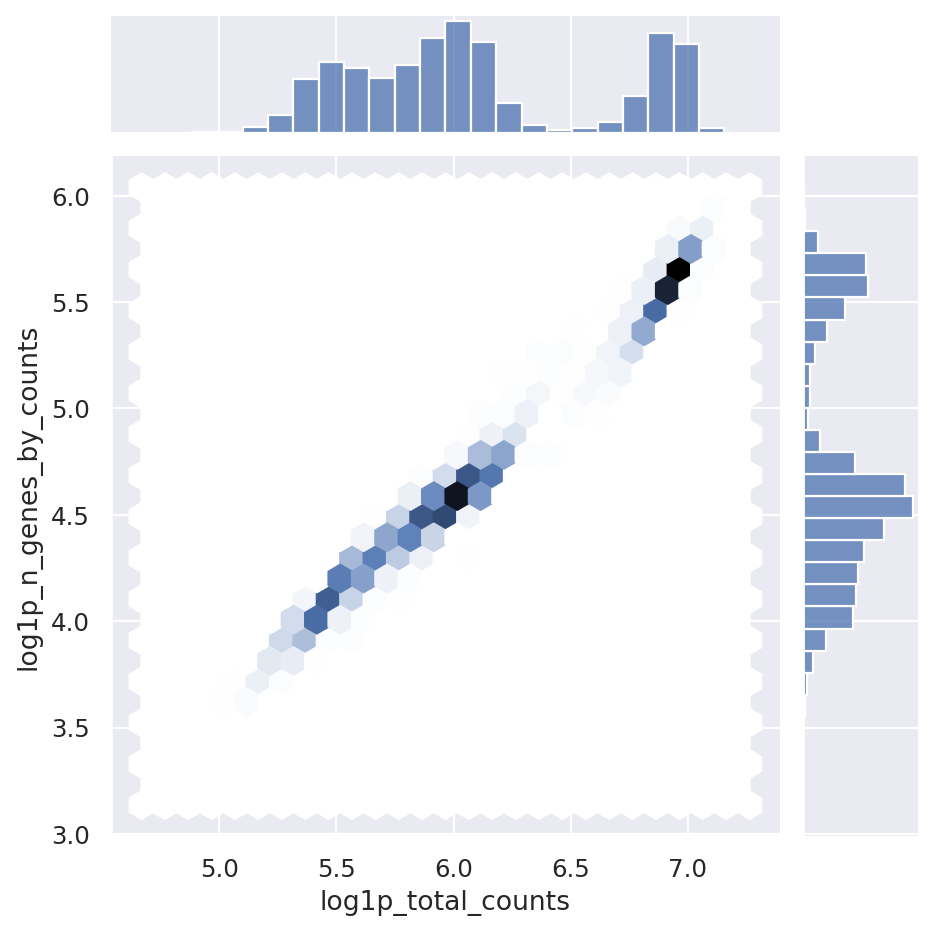

In [ ]:
import seaborn as sns
sns.jointplot(
    data=adata2.obs,
    x="log1p_total_counts",
    y="log1p_n_genes_by_counts",
    kind="hex",
)

<Axes: xlabel='pct_counts_rbp', ylabel='Count'>

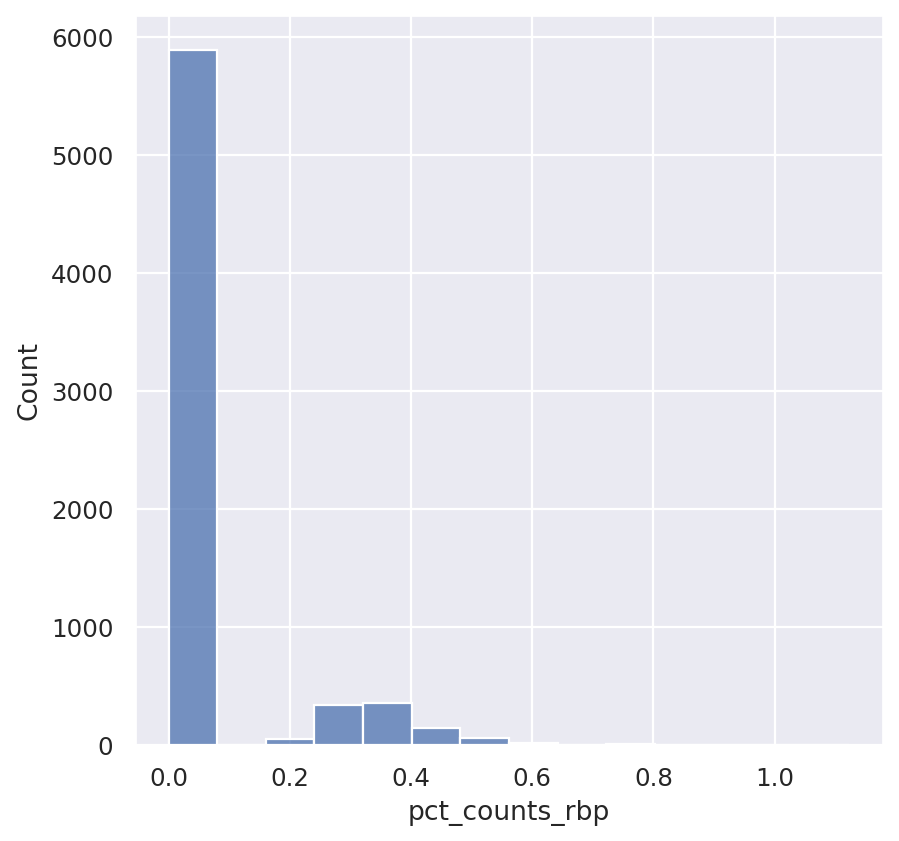

In [ ]:
sns.histplot(adata2.obs["pct_counts_rbp"])